In [1]:
library(Seurat)

Warning message:
“程辑包‘Seurat’是用R版本4.3.3 来建造的”
载入需要的程辑包：SeuratObject

Warning message:
“程辑包‘SeuratObject’是用R版本4.3.3 来建造的”
载入需要的程辑包：sp

Warning message:
“程辑包‘sp’是用R版本4.3.2 来建造的”

载入程辑包：‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
all_cor <- readRDS(paste0(indir,"/10-all_correlations_20241230.rds"))

In [3]:
head(all_cor);dim(all_cor);all_cor

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr1_100,0.2722892,5hmCG
chr1_1000,0.3520104,5hmCG
chr1_1001,0.3348554,5hmCG
chr1_1002,0.3059104,5hmCG
chr1_1003,0.3058775,5hmCG
chr1_1004,0.2738139,5hmCG


[1] 144191      3

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr1_100,0.27228924,5hmCG
chr1_1000,0.35201039,5hmCG
chr1_1001,0.33485536,5hmCG
chr1_1002,0.30591040,5hmCG
chr1_1003,0.30587751,5hmCG
chr1_1004,0.27381388,5hmCG
chr1_1005,0.22255811,5hmCG
chr1_1006,0.25612252,5hmCG
chr1_1007,0.19559169,5hmCG


In [4]:
all_cor[all_cor$chrom100k == "chr2_68",]

chrom100k,correlation,Group
<chr>,<dbl>,<fct>
chr2_68,-0.6408221,5hmCG
chr2_68,-0.7009343,5hmCG+5mCG
chr2_68,-0.5631858,5mCG
chr2_68,0.3284668,5hmCH
chr2_68,-0.3789414,5hmCH+5mCH
chr2_68,-0.3257154,5mCH


In [5]:
# all_cor[all_cor$chrom100k == "chr2_68",]

In [6]:
library(tidyr)

In [7]:
all_cor_wide <- all_cor %>%
  pivot_wider(names_from = Group,
              values_from = correlation)

In [8]:
head(all_cor_wide);dim(all_cor_wide)

chrom100k,5hmCG,5hmCG+5mCG,5mCG,5hmCH,5hmCH+5mCH,5mCH
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_100,0.2722892,0.61345976,-0.0019320,-0.01026757,0.5248297,0.5784408
chr1_1000,0.3520104,0.28136698,-0.2662400,0.49735946,0.3628129,0.2765961
chr1_1001,0.3348554,0.22803690,-0.2530475,0.60022774,0.3846170,0.2863597
chr1_1002,0.3059104,0.14403797,-0.2983956,0.60603801,0.3394747,0.2597545
chr1_1003,0.3058775,0.16454837,-0.2818965,0.43503489,0.3740543,0.3123230
chr1_1004,0.2738139,0.09907328,-0.2758789,0.48572102,0.3569702,0.2956227


[1] 24032     7

In [9]:
library(ggplot2)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..level..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(level)` instead.”
Warning message:
“Removed 296 rows containing non-finite outside the scale range
(`stat_density2d()`).”
Warning message:
“Removed 296 rows containing missing values or values outside the scale range
(`geom_point()`).”


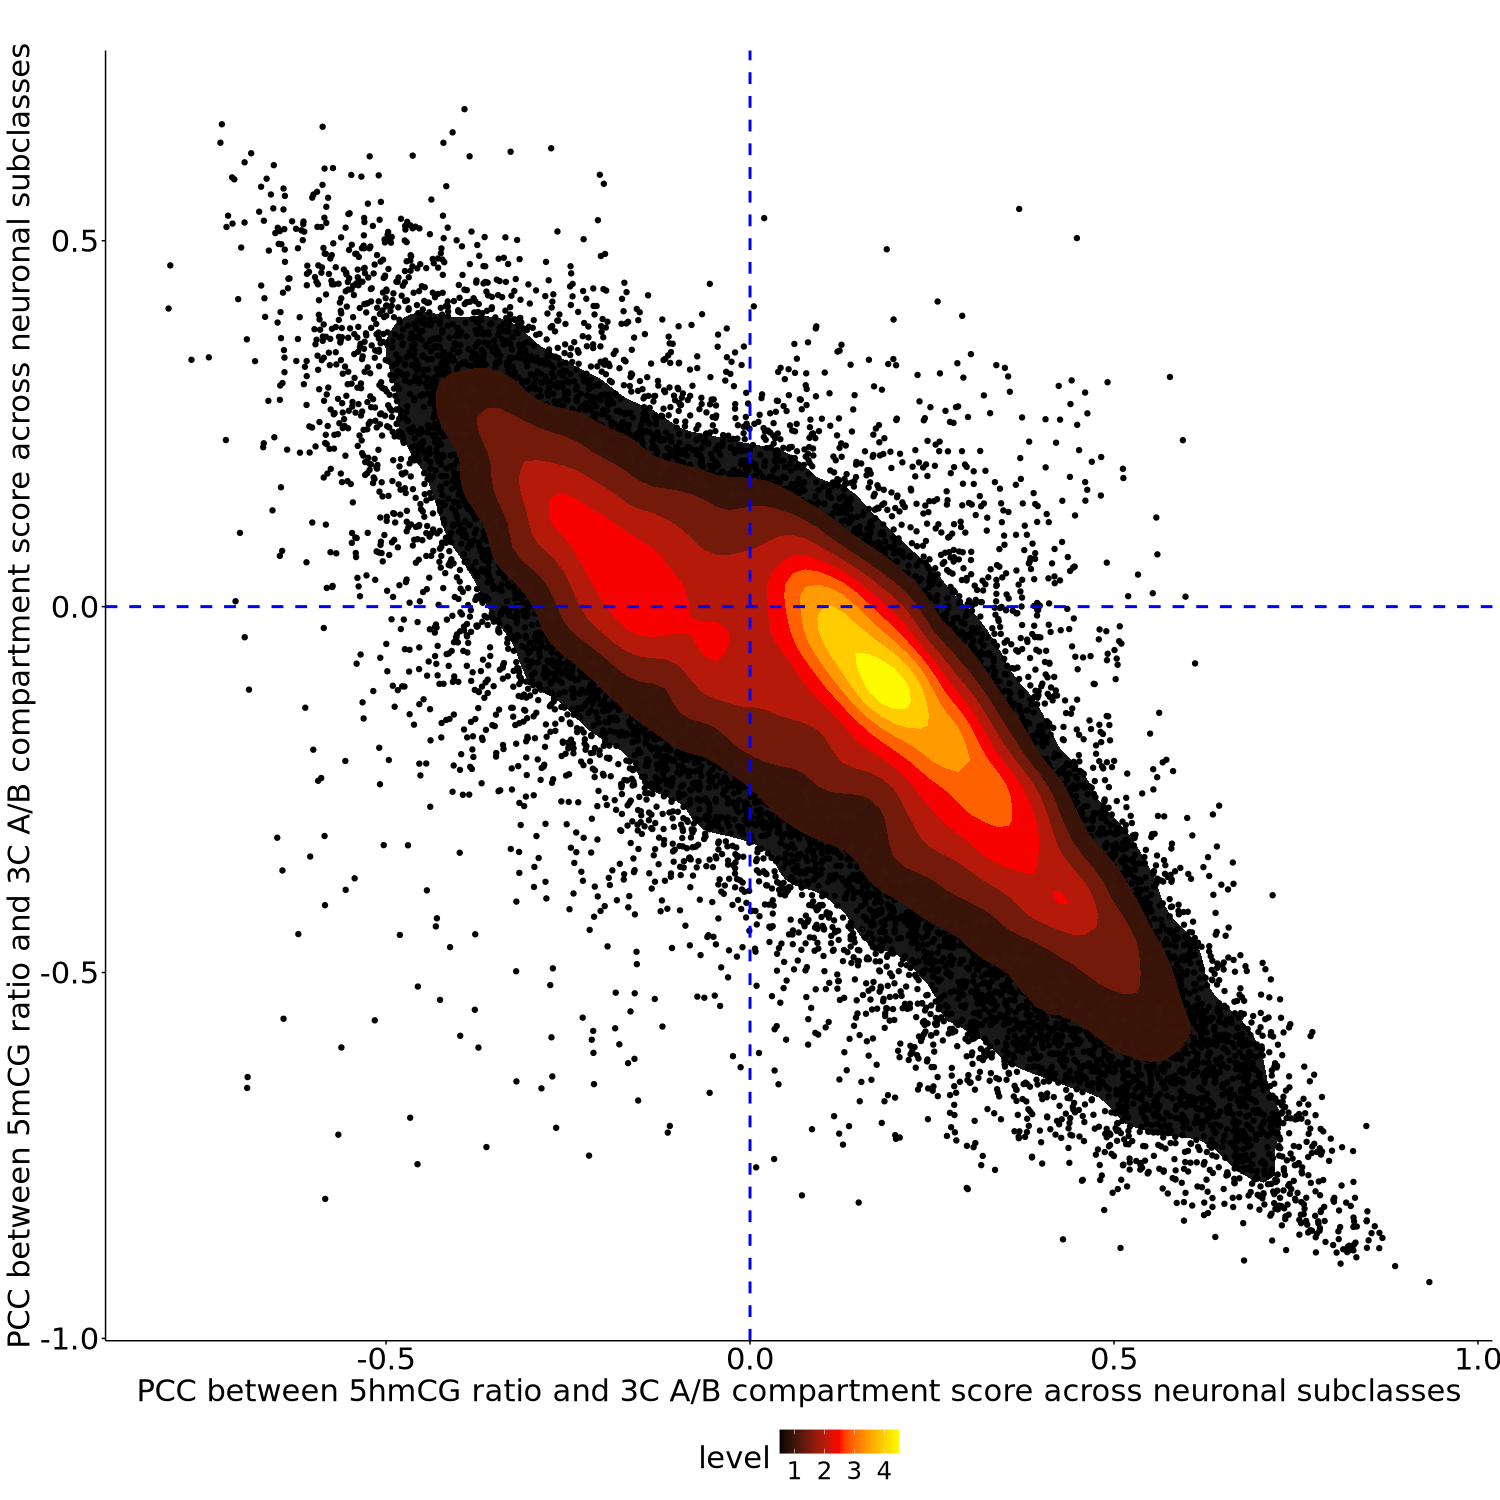

In [10]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)
ggplot(all_cor_wide, aes(x = `5hmCG`, y = `5mCG`)) +
  geom_point(color = "black", alpha = 1, size = 1.5) +
  stat_density_2d(aes(fill = ..level..), geom = "polygon", alpha = 0.9, 
                  h = c(0.1, 0.1), n = 100) +
  scale_fill_gradientn(colors = c("black", "red", "yellow")) +
#   geom_smooth(method = "loess", se = FALSE, color = "purple", size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "blue", size = 1) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "blue", size = 1) +
  labs(x = "PCC between 5hmCG ratio and 3C A/B compartment score across neuronal subclasses", 
       y = "PCC between 5mCG ratio and 3C A/B compartment score across neuronal subclasses", title = "") +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    axis.ticks = element_line(color = "black"),
    axis.text.x = element_text(size = 22),
    axis.text.y = element_text(size = 22),
    strip.text = element_text(color = "black"),
    plot.title = element_text(hjust = 0.5, color = "black"),
    legend.position = "bottom",
    text = element_text(size = 22)
  )

In [ ]:
# merged_df_max_5hmCG <- readRDS("/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/output/10-merged_df_max_5hmCG_neuron_and_non_neuron.rds")
merged_df_top100_5hmCG <- readRDS(paste0(indir,"/10-merged_df_top100_3C_5hmCG_neuron.rds"))

In [12]:
library(tidyverse)

Warning message:
“程辑包‘tidyverse’是用R版本4.3.3 来建造的”
Warning message:
“程辑包‘readr’是用R版本4.3.3 来建造的”
Warning message:
“程辑包‘dplyr’是用R版本4.3.2 来建造的”
Warning message:
“程辑包‘stringr’是用R版本4.3.2 来建造的”
Warning message:
“程辑包‘forcats’是用R版本4.3.3 来建造的”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [13]:
# rownames(merged_df_top100_5hmCG) <- NULL
# merged_df_top100_5hmCG <- merged_df_top100_5hmCG %>% column_to_rownames("chrom100k")
merged_df_seleted <- merged_df_top100_5hmCG[c('chr7_903','chr5_201','chr2_390','chr8_173','chr8_171','chr8_172'),]

In [14]:
merged_df_seleted

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,CLA-EPd-CTX Car3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr7_903,1.7105392,2.856917,3.512898,2.959611,2.4189963,4.824448,1.0355546,-1.9332246,-0.5480429,1.544318,⋯,3.7674706,4.258552,3.786138,-0.5911002,0.1942439,-0.6029984,-6.747073,10.146478,-1.014756,8.945236
chr5_201,-5.6518192,1.488893,4.314856,5.053926,-0.1388017,6.124374,-2.0613821,0.7477111,-3.0665140,-3.305445,⋯,-4.4319019,3.718318,3.858795,-10.0667868,-9.6159811,-1.6083663,-15.047481,13.807653,-8.250319,-18.941586
chr2_390,0.5715855,5.248351,9.250517,6.645447,6.1526594,8.878694,0.2993077,2.6003311,4.7639027,-2.146857,⋯,5.6781569,8.586951,5.509015,-3.7940540,-2.6354773,3.9414859,-7.530856,1.247645,2.019559,8.614120
chr8_173,7.7219462,7.193171,6.914012,6.068660,1.9922826,7.413206,5.8130345,5.7889137,2.5326810,9.055837,⋯,-2.2676432,6.207729,6.206310,7.5312934,6.0488334,3.6594610,-12.860137,-10.633036,14.279561,-18.813234
chr8_171,9.8715839,9.741956,9.032305,8.787358,2.8193302,8.723046,7.0606318,6.9741530,4.2692890,10.123658,⋯,-0.3049224,9.329975,8.034087,9.2162485,8.3411188,3.3317077,-12.178854,-12.419855,15.506176,-18.920788
chr8_172,8.2225485,7.956738,7.734872,7.306526,2.4553394,7.988753,6.1674099,5.9111171,3.0791759,9.637722,⋯,-1.1946702,7.529195,7.132567,8.1473866,7.0011683,3.5897856,-12.734256,-12.289319,15.034841,-18.901043


In [ ]:
UMAP <- readRDS(paste0(indir,"/04-RNA_UMAP.rds"))
head(UMAP);dim(UMAP)

,umap_1,umap_2
,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310


[1] 44608     2

In [ ]:
RNA_qc <- read.csv("../../../04.data/02.metainfo/01.Young_Mouse/TSO-joint.RNA_QC_stat.young.csv")

In [17]:
head(RNA_qc);dim(RNA_qc)

,SampleID,Plate_ID,Species,Total_reads,Clean_Reads,Reads_Clean_rate,Base_Clean_rate,reads_aligned,Align_rate,unique_reads_aligned,⋯,QC,Unique_ID,Region,Brain_region,SampleID_without_barcode,Batch,class_label,subclass_label,three_class_label,Neuron_non_neuron
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AACCAGAG,P49_Male_Hippo_TSO_RNA_plate1,mm10,742598,735450,1.00%,26.00%,532820,72.45%,522172,⋯,1,P49_Male_Hippo_TSO_plate1.AACCAGAG,Hippo,Hippo,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1,230912-0914-0915,IT-ET Glut,CA1-ProS Glut,Exc,Neuron
2,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AAGACACC,P49_Male_Hippo_TSO_RNA_plate1,mm10,488000,483618,1.00%,26.00%,373028,77.13%,362272,⋯,1,P49_Male_Hippo_TSO_plate1.AAGACACC,Hippo,Hippo,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1,230912-0914-0915,IT-ET Glut,SUB-ProS Glut,Exc,Neuron
3,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AAGACCGT,P49_Male_Hippo_TSO_RNA_plate1,mm10,814884,807220,1.00%,27.00%,618938,76.67%,597052,⋯,1,P49_Male_Hippo_TSO_plate1.AAGACCGT,Hippo,Hippo,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1,230912-0914-0915,IT-ET Glut,CA1-ProS Glut,Exc,Neuron
4,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AGACCTTG,P49_Male_Hippo_TSO_RNA_plate1,mm10,824766,816506,2.00%,26.00%,610342,74.75%,589770,⋯,1,P49_Male_Hippo_TSO_plate1.AGACCTTG,Hippo,Hippo,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1,230912-0914-0915,IT-ET Glut,SUB-ProS Glut,Exc,Neuron
5,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AGACGCTA,P49_Male_Hippo_TSO_RNA_plate1,mm10,738248,731106,1.00%,27.00%,552100,75.52%,534652,⋯,1,P49_Male_Hippo_TSO_plate1.AGACGCTA,Hippo,Hippo,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1,230912-0914-0915,IT-ET Glut,SUB-ProS Glut,Exc,Neuron
6,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AGCCTATC,P49_Male_Hippo_TSO_RNA_plate1,mm10,503566,498414,2.00%,27.00%,388296,77.90%,379750,⋯,1,P49_Male_Hippo_TSO_plate1.AGCCTATC,Hippo,Hippo,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1,230912-0914-0915,CTX-CGE GABA,Sncg Gaba,Inh,Neuron


[1] 47712    44

In [18]:
table(rownames(UMAP) %in% RNA_qc$Unique_ID)


 TRUE 
44608 

In [19]:
UMAP$subclass <- RNA_qc$subclass_label[match(rownames(UMAP),RNA_qc$Unique_ID)]

In [20]:
head(UMAP);dim(UMAP)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut


[1] 44608     3

In [21]:
unique(UMAP$subclass)

[1] "L2/3 IT CTX Glut"      "ACB-BST-FS D1 Gaba"    "L5 IT CTX Glut"       
 [4] "Astro-TE NN"           "L4/5 IT CTX Glut"      "L5 ET CTX Glut"       
 [7] "L6 CT CTX Glut"        "STR D1 Gaba"           "Microglia NN"         
[10] "Oligo NN"              "CLA-EPd-CTX Car3 Glut" "Lamp5 Gaba"           
[13] "Sncg Gaba"             "OPC NN"                "SUB-ProS Glut"        
[16] "L2/3 IT RSP Glut"      "DG Glut"               "Pvalb Gaba"           
[19] "CA3 Glut"              "L4 RSP-ACA Glut"       "Sst Gaba"             
[22] "OB-STR-CTX Inh IMN"    "OEC NN"                "L5 NP CTX Glut"       
[25] "OB-in Frmd7 Gaba"      "OB Eomes Ms4a15 Glut"  "OB-out Frmd7 Gaba"    
[28] "OB Dopa-Gaba"          "CA1-ProS Glut"         "STR D2 Gaba"

In [22]:
# UMAP <- UMAP[!UMAP$subclass %in% c('Astro-TE NN','Microglia NN','Oligo NN','OPC NN','OEC NN'),]
UMAP <- UMAP[!UMAP$subclass %in% c('OEC NN'),]

In [23]:
library(dplyr)

In [24]:
# merged_df_max_3C <- merged_df_max_5hmCG %>%
#   select(ends_with("_3C"))

In [25]:
merged_df_max_3C <- merged_df_seleted
merged_df_max_3C

,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,SUB-ProS Glut,CA1-ProS Glut,CA3 Glut,CLA-EPd-CTX Car3 Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr7_903,1.7105392,2.856917,3.512898,2.959611,2.4189963,4.824448,1.0355546,-1.9332246,-0.5480429,1.544318,⋯,3.7674706,4.258552,3.786138,-0.5911002,0.1942439,-0.6029984,-6.747073,10.146478,-1.014756,8.945236
chr5_201,-5.6518192,1.488893,4.314856,5.053926,-0.1388017,6.124374,-2.0613821,0.7477111,-3.0665140,-3.305445,⋯,-4.4319019,3.718318,3.858795,-10.0667868,-9.6159811,-1.6083663,-15.047481,13.807653,-8.250319,-18.941586
chr2_390,0.5715855,5.248351,9.250517,6.645447,6.1526594,8.878694,0.2993077,2.6003311,4.7639027,-2.146857,⋯,5.6781569,8.586951,5.509015,-3.7940540,-2.6354773,3.9414859,-7.530856,1.247645,2.019559,8.614120
chr8_173,7.7219462,7.193171,6.914012,6.068660,1.9922826,7.413206,5.8130345,5.7889137,2.5326810,9.055837,⋯,-2.2676432,6.207729,6.206310,7.5312934,6.0488334,3.6594610,-12.860137,-10.633036,14.279561,-18.813234
chr8_171,9.8715839,9.741956,9.032305,8.787358,2.8193302,8.723046,7.0606318,6.9741530,4.2692890,10.123658,⋯,-0.3049224,9.329975,8.034087,9.2162485,8.3411188,3.3317077,-12.178854,-12.419855,15.506176,-18.920788
chr8_172,8.2225485,7.956738,7.734872,7.306526,2.4553394,7.988753,6.1674099,5.9111171,3.0791759,9.637722,⋯,-1.1946702,7.529195,7.132567,8.1473866,7.0011683,3.5897856,-12.734256,-12.289319,15.034841,-18.901043


In [26]:
# colnames(merged_df_max_3C) <- gsub("_3C$", "", colnames(merged_df_max_3C))

In [27]:
# merged_df_max_3C

In [28]:
head(UMAP);dim(UMAP)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut


[1] 44205     3

In [29]:
UMAP_filter <- UMAP[!UMAP$subclass %in% "OEC NN",]

In [30]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut


[1] 44205     3

In [31]:
merged_df_max_3C_t <- merged_df_max_3C %>% t()

In [32]:
merged_df_max_3C_t <- merged_df_max_3C_t %>% data.frame()

In [33]:
merged_df_max_3C_t

,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,1.7105392,-5.6518192,0.5715855,7.7219462,9.8715839,8.2225485
L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.1931705,9.7419558,7.9567375
L5 IT CTX Glut,3.5128977,4.3148556,9.2505169,6.9140124,9.0323048,7.7348723
L2/3 IT RSP Glut,2.9596107,5.0539260,6.6454468,6.0686598,8.7873583,7.3065262
L4 RSP-ACA Glut,2.4189963,-0.1388017,6.1526594,1.9922826,2.8193302,2.4553394
L5 ET CTX Glut,4.8244476,6.1243739,8.8786936,7.4132056,8.7230463,7.9887533
SUB-ProS Glut,1.0355546,-2.0613821,0.2993077,5.8130345,7.0606318,6.1674099
CA1-ProS Glut,-1.9332246,0.7477111,2.6003311,5.7889137,6.9741530,5.9111171
CA3 Glut,-0.5480429,-3.0665140,4.7639027,2.5326810,4.2692890,3.0791759


In [34]:
# merged_df_max_3C_t <- merged_df_max_3C_t[-c(26:28),]

In [35]:
merged_df_max_3C_t

,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,1.7105392,-5.6518192,0.5715855,7.7219462,9.8715839,8.2225485
L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.1931705,9.7419558,7.9567375
L5 IT CTX Glut,3.5128977,4.3148556,9.2505169,6.9140124,9.0323048,7.7348723
L2/3 IT RSP Glut,2.9596107,5.0539260,6.6454468,6.0686598,8.7873583,7.3065262
L4 RSP-ACA Glut,2.4189963,-0.1388017,6.1526594,1.9922826,2.8193302,2.4553394
L5 ET CTX Glut,4.8244476,6.1243739,8.8786936,7.4132056,8.7230463,7.9887533
SUB-ProS Glut,1.0355546,-2.0613821,0.2993077,5.8130345,7.0606318,6.1674099
CA1-ProS Glut,-1.9332246,0.7477111,2.6003311,5.7889137,6.9741530,5.9111171
CA3 Glut,-0.5480429,-3.0665140,4.7639027,2.5326810,4.2692890,3.0791759


In [36]:
# colnames(merged_df_max_3C_t) <- "Compartment score"
# merged_df_max_3C_t

In [37]:
table(UMAP_filter$subclass %in% rownames(merged_df_max_3C_t))


 TRUE 
44205 

In [38]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass
,<dbl>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut


[1] 44205     3

In [39]:
merged_df_max_3C_t_aaa <- merged_df_max_3C_t %>%
  tibble::rownames_to_column("subclass")

In [40]:
merged_df_max_3C_t_aaa

subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
L2/3 IT CTX Glut,1.7105392,-5.6518192,0.5715855,7.7219462,9.8715839,8.2225485
L4/5 IT CTX Glut,2.8569169,1.4888928,5.2483511,7.1931705,9.7419558,7.9567375
L5 IT CTX Glut,3.5128977,4.3148556,9.2505169,6.9140124,9.0323048,7.7348723
L2/3 IT RSP Glut,2.9596107,5.0539260,6.6454468,6.0686598,8.7873583,7.3065262
L4 RSP-ACA Glut,2.4189963,-0.1388017,6.1526594,1.9922826,2.8193302,2.4553394
L5 ET CTX Glut,4.8244476,6.1243739,8.8786936,7.4132056,8.7230463,7.9887533
SUB-ProS Glut,1.0355546,-2.0613821,0.2993077,5.8130345,7.0606318,6.1674099
CA1-ProS Glut,-1.9332246,0.7477111,2.6003311,5.7889137,6.9741530,5.9111171
CA3 Glut,-0.5480429,-3.0665140,4.7639027,2.5326810,4.2692890,3.0791759


In [41]:
UMAP_filter_merged <- UMAP_filter %>%
  left_join(merged_df_max_3C_t_aaa, by = "subclass")

In [42]:
UMAP_filter_merged

umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-10.619191,-3.3056249,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
-6.353836,1.9836286,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
6.901790,7.2563258,ACB-BST-FS D1 Gaba,-0.6029984,-1.608366,3.9414859,3.659461,3.331708,3.589786
-10.278223,-0.1804050,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
-8.274960,-4.0003082,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
-4.735382,-9.9543099,L5 IT CTX Glut,3.5128977,4.314856,9.2505169,6.914012,9.032305,7.734872
9.510513,-0.5799464,Astro-TE NN,-6.7470727,-15.047481,-7.5308557,-12.860137,-12.178854,-12.734256
-9.875563,-0.5495232,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
1.139027,3.1630243,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548


In [43]:
library(ggplot2)

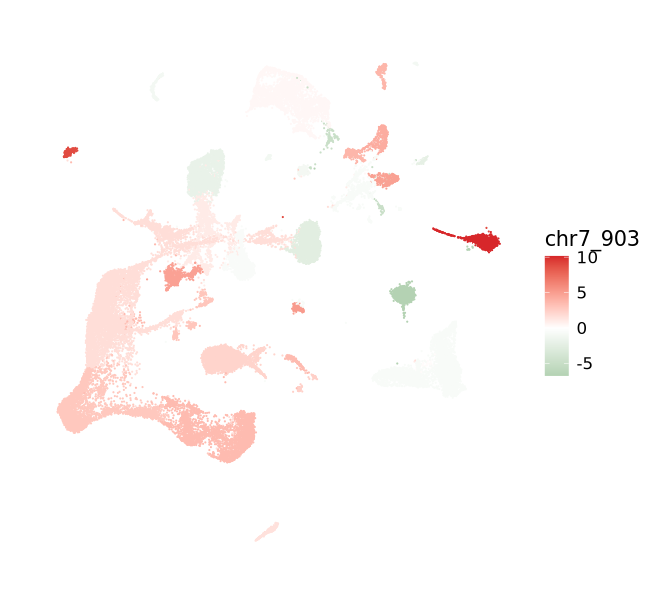

In [44]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#8FBC8F", high = "#D7272A")

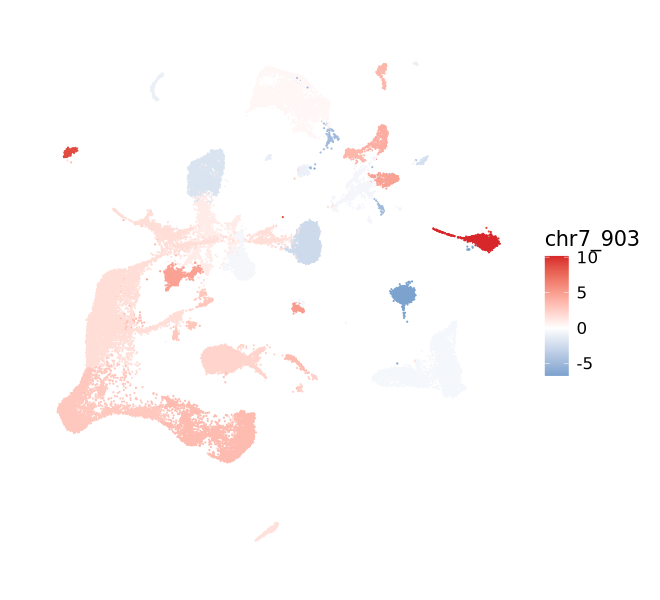

In [45]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

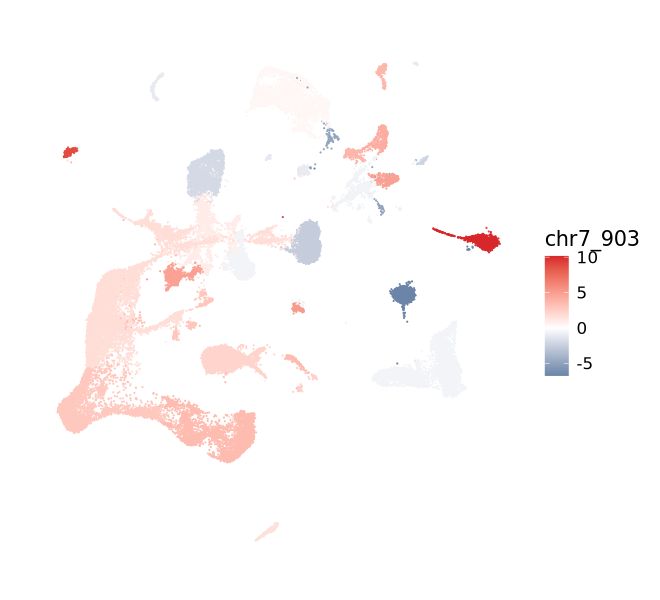

In [46]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#0D4D7D", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

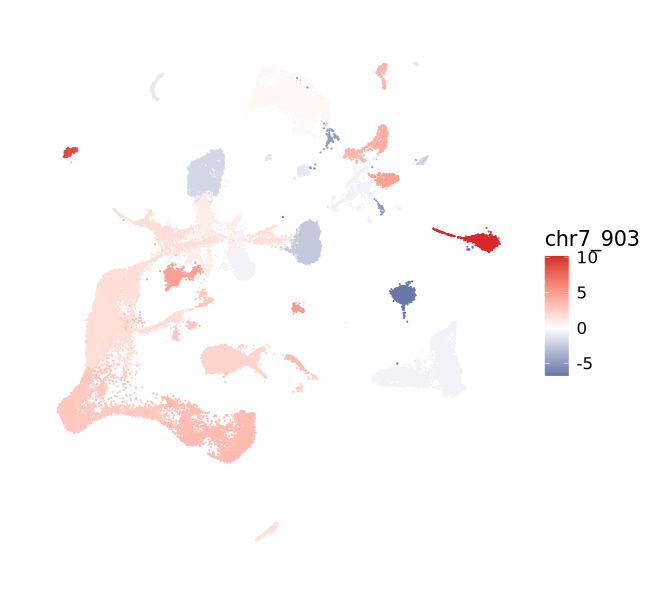

In [47]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#003C7D", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

In [48]:
library(scales)

Warning message:
“程辑包‘scales’是用R版本4.3.2 来建造的”

载入程辑包：‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




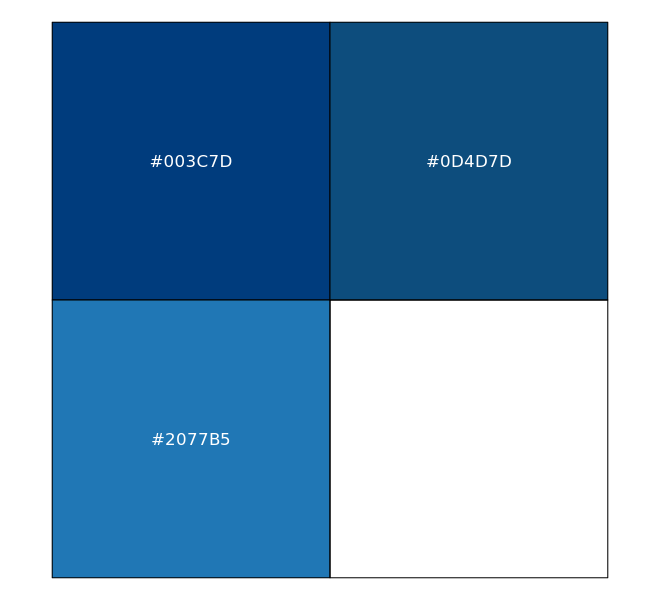

In [49]:
show_col(c("#003C7D","#0D4D7D","#2077B5"))

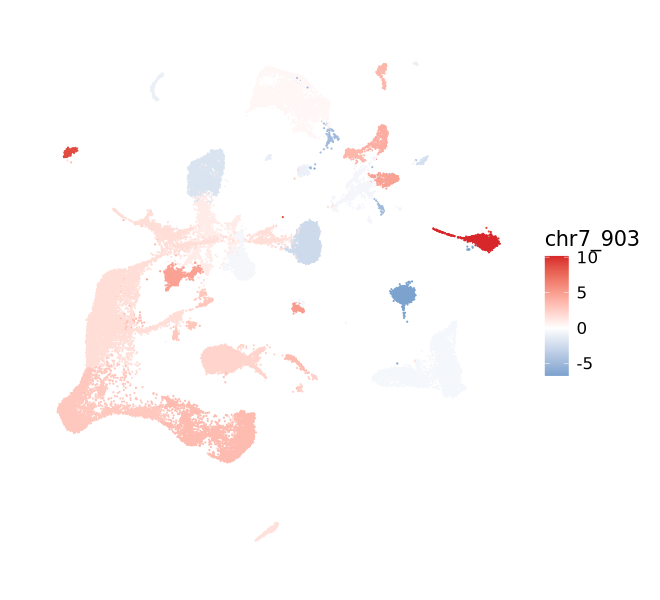

In [50]:
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0, 
                          limits = c(min(UMAP_filter_merged$`chr7_903`), max(UMAP_filter_merged$`chr7_903`)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-6.7471 -0.5911  1.7105  1.1529  2.8569 10.1465 

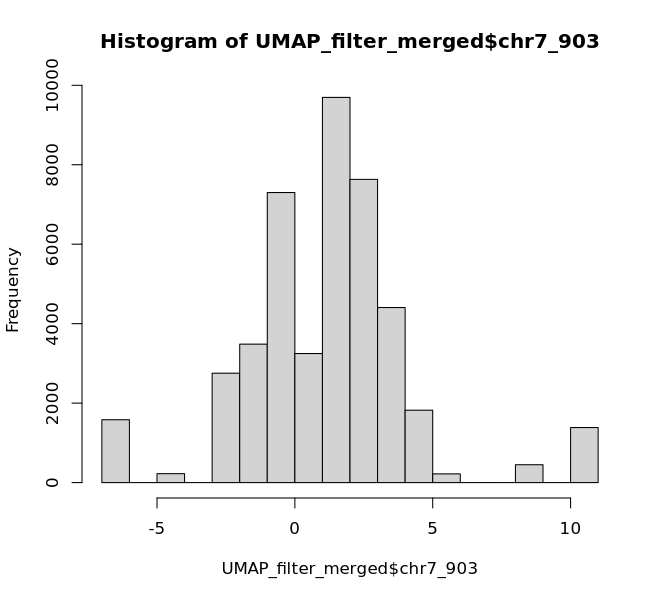

In [51]:
summary(UMAP_filter_merged$chr7_903)
hist(UMAP_filter_merged$chr7_903)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


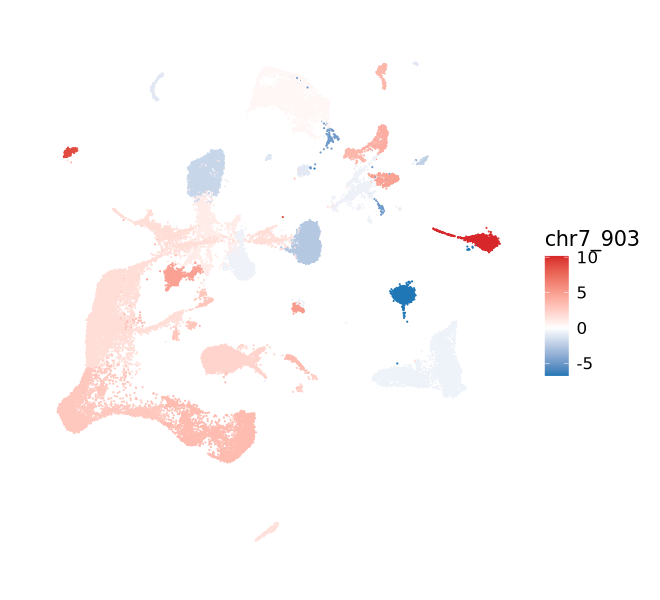

In [52]:
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(color = `chr7_903`), size = 0.1) +
  labs(x = "", y = "", title = "") +
  theme_minimal() +
  theme(
    text = element_text(size = 15), 
    panel.grid = element_blank(), 
    axis.text = element_blank(),
    axis.ticks = element_blank()
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903))),
    guide = "colorbar"
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903)))# ,
#     breaks = c(0)#,
#     labels = c("0")
  ) 

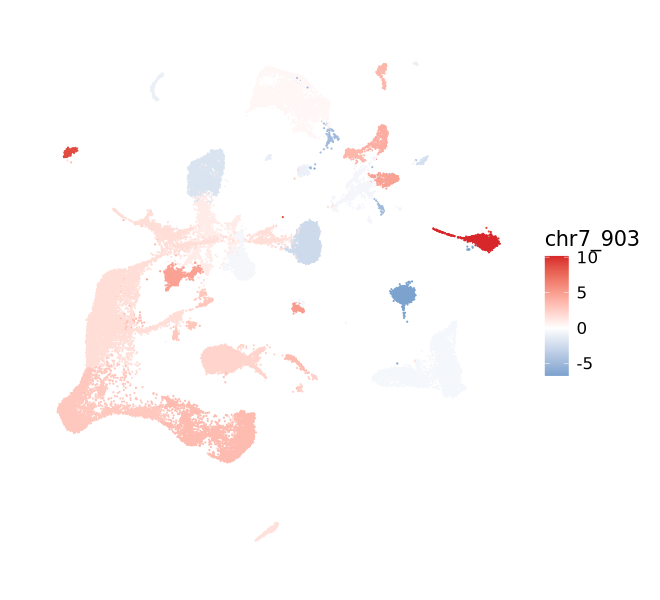

In [53]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter_merged, aes(x = umap_1, y = umap_2, color = `chr7_903`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
#     scale_color_gradient2(low = "#2077B5", high = "#D7272A")

In [54]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-10.619191,-3.305625,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
2,-6.353836,1.983629,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
3,6.901790,7.256326,ACB-BST-FS D1 Gaba,-0.6029984,-1.608366,3.9414859,3.659461,3.331708,3.589786
4,-10.278223,-0.180405,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
5,-8.274960,-4.000308,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
6,-4.735382,-9.954310,L5 IT CTX Glut,3.5128977,4.314856,9.2505169,6.914012,9.032305,7.734872


[1] 44205     9

In [ ]:
chrom100k_5hmCG <- read.csv(paste0(indir,"/11-extracted_chr7_903_5hmCG.csv"))
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

chrom100k_5mCG <- read.csv(paste0(indir,"/11-extracted_chr7_903_5mCG.csv"))
head(chrom100k_5mCG);dim(chrom100k_5mCG)

chrom100k_true5mCG <- read.csv(paste0(indir,"/11-extracted_chr7_903_true5mCG.csv"))
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)

,Unique_ID,chr7_903
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.2077922
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,NA
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.1466667
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.2985075
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.3103448
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.4146341


[1] 44608     2

,Unique_ID,chr7_903
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.6514523
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,1.0000000
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.8421053
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.8421053
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.8050848
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.7600000


[1] 44608     2

,Unique_ID,chr7_903
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.4436601
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,NA
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.6954386
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.5435978
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.4947399
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.3453658


[1] 44608     2

In [56]:
RNA_qc_subset <- RNA_qc %>%
  select(Unique_ID, subclass_label)

In [57]:
head(RNA_qc_subset);dim(RNA_qc_subset)

,Unique_ID,subclass_label
,<chr>,<chr>
1,P49_Male_Hippo_TSO_plate1.AACCAGAG,CA1-ProS Glut
2,P49_Male_Hippo_TSO_plate1.AAGACACC,SUB-ProS Glut
3,P49_Male_Hippo_TSO_plate1.AAGACCGT,CA1-ProS Glut
4,P49_Male_Hippo_TSO_plate1.AGACCTTG,SUB-ProS Glut
5,P49_Male_Hippo_TSO_plate1.AGACGCTA,SUB-ProS Glut
6,P49_Male_Hippo_TSO_plate1.AGCCTATC,Sncg Gaba


[1] 47712     2

In [58]:
chrom100k_5hmCG <- chrom100k_5hmCG %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

,Unique_ID,chr7_903,subclass_label
,<chr>,<dbl>,<chr>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.2077922,L2/3 IT CTX Glut
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,NA,L2/3 IT CTX Glut
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.1466667,ACB-BST-FS D1 Gaba
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.2985075,L2/3 IT CTX Glut
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.3103448,L2/3 IT CTX Glut
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.4146341,L5 IT CTX Glut


[1] 44608     3

In [59]:
chrom100k_5hmCG <- chrom100k_5hmCG %>%
  group_by(subclass_label) %>%
  mutate(chr7_903 = ifelse(is.na(chr7_903), mean(chr7_903, na.rm = TRUE), chr7_903)) %>%
  ungroup()
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)
table(is.na(chrom100k_5hmCG$chr7_903))

Unique_ID,chr7_903,subclass_label
<chr>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.2077922,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.2588121,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.1466667,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.2985075,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.3103448,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.4146341,L5 IT CTX Glut


[1] 44608     3


FALSE 
44608 

In [60]:
chrom100k_5mCG <- chrom100k_5mCG %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
head(chrom100k_5mCG);dim(chrom100k_5mCG)

chrom100k_true5mCG <- chrom100k_true5mCG %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)

,Unique_ID,chr7_903,subclass_label
,<chr>,<dbl>,<chr>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.6514523,L2/3 IT CTX Glut
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,1.0000000,L2/3 IT CTX Glut
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.8421053,ACB-BST-FS D1 Gaba
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.8421053,L2/3 IT CTX Glut
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.8050848,L2/3 IT CTX Glut
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.7600000,L5 IT CTX Glut


[1] 44608     3

,Unique_ID,chr7_903,subclass_label
,<chr>,<dbl>,<chr>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.4436601,L2/3 IT CTX Glut
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,NA,L2/3 IT CTX Glut
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.6954386,ACB-BST-FS D1 Gaba
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.5435978,L2/3 IT CTX Glut
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.4947399,L2/3 IT CTX Glut
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.3453658,L5 IT CTX Glut


[1] 44608     3

In [61]:
chrom100k_5mCG <- chrom100k_5mCG %>%
  group_by(subclass_label) %>%
  mutate(chr7_903 = ifelse(is.na(chr7_903), mean(chr7_903, na.rm = TRUE), chr7_903)) %>%
  ungroup()
head(chrom100k_5mCG);dim(chrom100k_5mCG)
table(is.na(chrom100k_5mCG$chr7_903))

chrom100k_true5mCG <- chrom100k_true5mCG %>%
  group_by(subclass_label) %>%
  mutate(chr7_903 = ifelse(is.na(chr7_903), mean(chr7_903, na.rm = TRUE), chr7_903)) %>%
  ungroup()
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)
table(is.na(chrom100k_true5mCG$chr7_903))

Unique_ID,chr7_903,subclass_label
<chr>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.6514523,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,1.0000000,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.8421053,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.8421053,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.8050848,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.7600000,L5 IT CTX Glut


[1] 44608     3


FALSE 
44608 

Unique_ID,chr7_903,subclass_label
<chr>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.4436601,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.5459036,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.6954386,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.5435978,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.4947399,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.3453658,L5 IT CTX Glut


[1] 44608     3


FALSE 
44608 

In [62]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-10.619191,-3.305625,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
2,-6.353836,1.983629,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
3,6.901790,7.256326,ACB-BST-FS D1 Gaba,-0.6029984,-1.608366,3.9414859,3.659461,3.331708,3.589786
4,-10.278223,-0.180405,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
5,-8.274960,-4.000308,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
6,-4.735382,-9.954310,L5 IT CTX Glut,3.5128977,4.314856,9.2505169,6.914012,9.032305,7.734872


[1] 44205     9

In [63]:
identical(UMAP_filter_merged$umap_1,UMAP_filter$umap_1)

[1] TRUE

In [64]:
rownames(UMAP_filter_merged) <- NULL
rownames(UMAP_filter_merged) <- rownames(UMAP_filter)
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-0.6029984,-1.608366,3.9414859,3.659461,3.331708,3.589786
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,3.5128977,4.314856,9.2505169,6.914012,9.032305,7.734872


[1] 44205     9

In [65]:
UMAP_filter_chr7_903 <- UMAP_filter_merged[,c("umap_1","umap_2","subclass","chr7_903")]
colnames(UMAP_filter_chr7_903) <- c("umap_1","umap_2","subclass","Compartment score")
head(UMAP_filter_chr7_903);dim(UMAP_filter_chr7_903)

,umap_1,umap_2,subclass,Compartment score
,<dbl>,<dbl>,<chr>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,1.7105392
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,1.7105392
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-0.6029984
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,1.7105392
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,1.7105392
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,3.5128977


[1] 44205     4

In [66]:
UMAP_filter_chr7_903$`5hmCG` <- chrom100k_5hmCG$chr7_903[match(rownames(UMAP_filter_chr7_903),chrom100k_5hmCG$Unique_ID)]
UMAP_filter_chr7_903$`5hmCG+5mCG` <- chrom100k_5mCG$chr7_903[match(rownames(UMAP_filter_chr7_903),chrom100k_5mCG$Unique_ID)]
UMAP_filter_chr7_903$`5mCG` <- chrom100k_true5mCG$chr7_903[match(rownames(UMAP_filter_chr7_903),chrom100k_true5mCG$Unique_ID)]

In [67]:
head(UMAP_filter_chr7_903);dim(UMAP_filter_chr7_903)

,umap_1,umap_2,subclass,Compartment score,5hmCG,5hmCG+5mCG,5mCG
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,1.7105392,0.2077922,0.6514523,0.4436601
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,1.7105392,0.2588121,1.0000000,0.5459036
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-0.6029984,0.1466667,0.8421053,0.6954386
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,1.7105392,0.2985075,0.8421053,0.5435978
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,1.7105392,0.3103448,0.8050848,0.4947399
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,3.5128977,0.4146341,0.7600000,0.3453658


[1] 44205     7

In [68]:
UMAP_filter_chr7_903[["5hmCG"]] <- pmin(pmax(UMAP_filter_chr7_903[["5hmCG"]], 0.2), 0.5)

In [69]:
p2 <- ggplot(UMAP_filter_chr7_903[,c("umap_1","umap_2","5hmCG")], aes(x = umap_1, y = umap_2, color = `5hmCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.2, 0.5), breaks = c(0.2, 0.5))

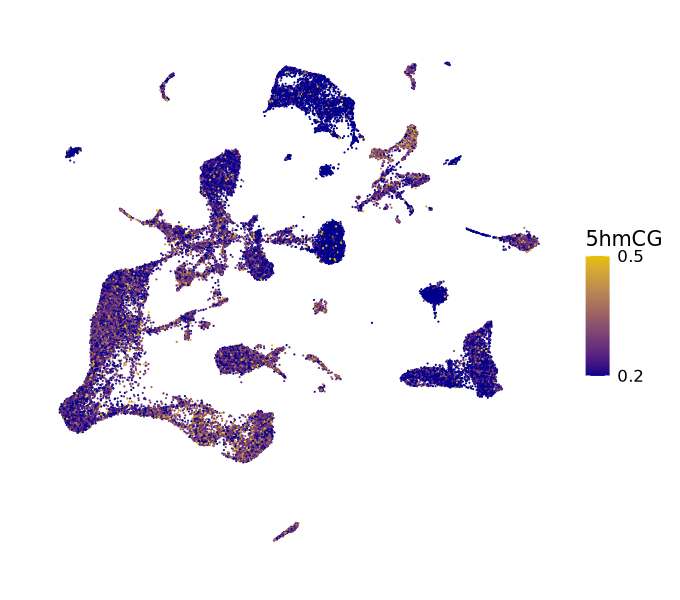

In [70]:
options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
p2

In [71]:
UMAP_filter_chr7_903[["5hmCG+5mCG"]] <- pmin(pmax(UMAP_filter_chr7_903[["5hmCG+5mCG"]], 0.3), 1)

In [72]:
p3 <- ggplot(UMAP_filter_chr7_903[,c("umap_1","umap_2","5hmCG+5mCG")], aes(x = umap_1, y = umap_2, color = `5hmCG+5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.3, 1), breaks = c(0.3, 1))

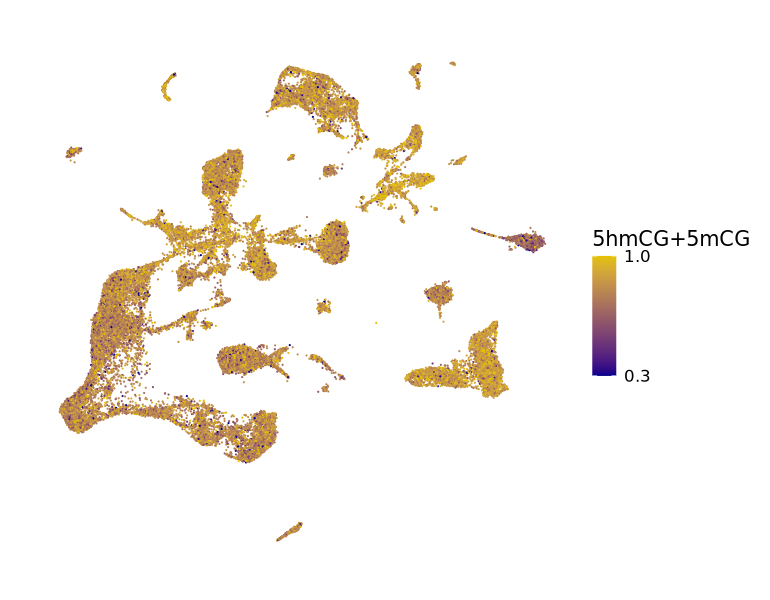

In [73]:
options(repr.plot.width = 7.7, repr.plot.height = 6, repr.plot.res = 100)
p3

In [74]:
UMAP_filter_chr7_903[["5mCG"]] <- pmin(pmax(UMAP_filter_chr7_903[["5mCG"]], 0.3), 0.8)

In [75]:
p4 <- ggplot(UMAP_filter_chr7_903[,c("umap_1","umap_2","5mCG")], aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.3, 0.8), breaks = c(0.3, 0.8))

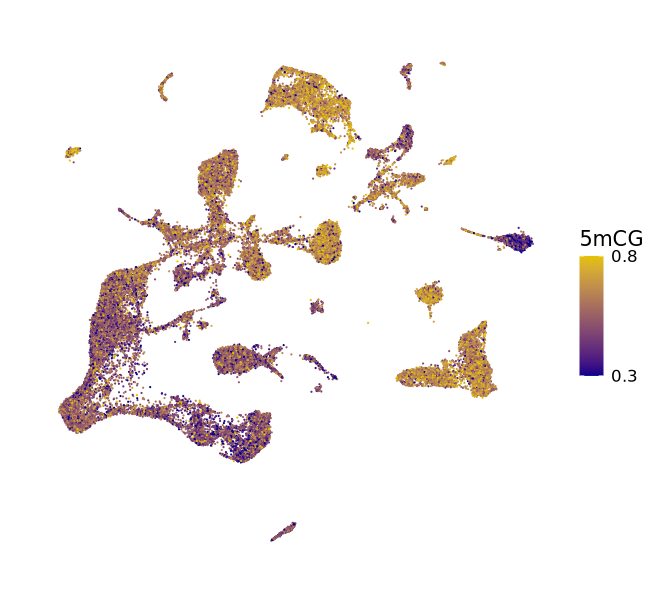

In [76]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
p4

In [77]:
p1 <- ggplot(UMAP_filter_chr7_903, aes(x = umap_1, y = umap_2)) +
  geom_point(aes(color = `Compartment score`), size = 0.1) +
  labs(x = "", y = "", title = "") +
  theme_minimal() +
  theme(
    text = element_text(size = 15), 
    panel.grid = element_blank(), 
    axis.text = element_blank(),
    axis.ticks = element_blank()
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903))),
    guide = "colorbar"
  ) +
  scale_color_gradientn(
    colors = c("#2077B5", "#FFFFFF", "#D7272A"),
    values = scales::rescale(c(min(UMAP_filter_merged$chr7_903), 0, max(UMAP_filter_merged$chr7_903)))# ,
#     breaks = c(0)#,
#     labels = c("0")
  ) 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


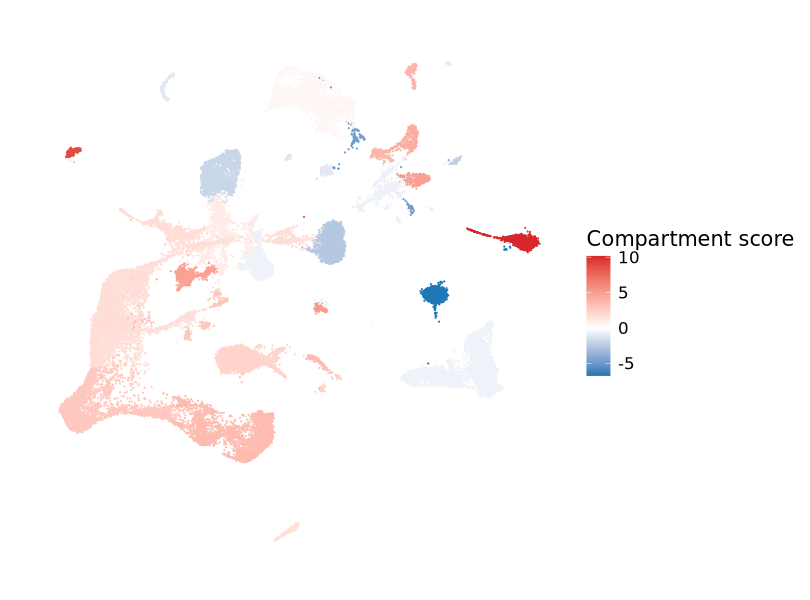

In [78]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
p1

In [79]:
library(gridExtra)
library(ggplot2)


载入程辑包：‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [80]:
gpp1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(8.1, "inches"))
gpp2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(6.8, "inches"))
gpp3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(7.7, "inches"))
gpp4 <- arrangeGrob(p4, heights = unit(6, "inches"), widths = unit(6.6, "inches"))

In [81]:
combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, ncol = 4, nrow = 1)

In [ ]:
# ggsave("/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/output/12-UMAP_chr7_903_show_3C_DNA_methyl_including_non_neuron_20250120.pdf", 
#        combined_plot, 
#        width = 32, height = 6)

In [83]:
process_chrom_column <- function(column_name, UMAP_filter_merged, RNA_qc, output_dir, range_5hmCG = c(0.2, 0.5), range_5hmCG_5mCG = c(0.3, 1), range_5mCG = c(0.3, 1)) {

  chrom_5hmCG <- read.csv(paste0(output_dir, "/11-extracted_", column_name, "_5hmCG.csv"))
  chrom_5mCG <- read.csv(paste0(output_dir, "/11-extracted_", column_name, "_5mCG.csv"))
  chrom_true5mCG <- read.csv(paste0(output_dir, "/11-extracted_", column_name, "_true5mCG.csv"))

  RNA_qc_subset <- RNA_qc %>% select(Unique_ID, subclass_label)

  chrom_5hmCG <- chrom_5hmCG %>% left_join(RNA_qc_subset, by = "Unique_ID")
  chrom_5mCG <- chrom_5mCG %>% left_join(RNA_qc_subset, by = "Unique_ID")
  chrom_true5mCG <- chrom_true5mCG %>% left_join(RNA_qc_subset, by = "Unique_ID")

  chrom_5hmCG <- chrom_5hmCG %>% group_by(subclass_label) %>% mutate(!!column_name := ifelse(is.na(!!sym(column_name)), mean(!!sym(column_name), na.rm = TRUE), !!sym(column_name))) %>% ungroup()
  chrom_5mCG <- chrom_5mCG %>% group_by(subclass_label) %>% mutate(!!column_name := ifelse(is.na(!!sym(column_name)), mean(!!sym(column_name), na.rm = TRUE), !!sym(column_name))) %>% ungroup()
  chrom_true5mCG <- chrom_true5mCG %>% group_by(subclass_label) %>% mutate(!!column_name := ifelse(is.na(!!sym(column_name)), mean(!!sym(column_name), na.rm = TRUE), !!sym(column_name))) %>% ungroup()

  UMAP_filter_column <- UMAP_filter_merged[, c("umap_1", "umap_2", "subclass", column_name)]
  colnames(UMAP_filter_column) <- c("umap_1", "umap_2", "subclass", "Compartment score")

  UMAP_filter_column$`5hmCG` <- chrom_5hmCG[[column_name]][match(rownames(UMAP_filter_column), chrom_5hmCG$Unique_ID)]
  UMAP_filter_column$`5hmCG+5mCG` <- chrom_5mCG[[column_name]][match(rownames(UMAP_filter_column), chrom_5mCG$Unique_ID)]
  UMAP_filter_column$`5mCG` <- chrom_true5mCG[[column_name]][match(rownames(UMAP_filter_column), chrom_true5mCG$Unique_ID)]

  UMAP_filter_column[["5hmCG"]] <- pmin(pmax(UMAP_filter_column[["5hmCG"]], range_5hmCG[1]), range_5hmCG[2])
  UMAP_filter_column[["5hmCG+5mCG"]] <- pmin(pmax(UMAP_filter_column[["5hmCG+5mCG"]], range_5hmCG_5mCG[1]), range_5hmCG_5mCG[2])
  UMAP_filter_column[["5mCG"]] <- pmin(pmax(UMAP_filter_column[["5mCG"]], range_5mCG[1]), range_5mCG[2])

  p1 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2)) +
    geom_point(aes(color = `Compartment score`), size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(
      text = element_text(size = 15),
      panel.grid = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    ) +
    scale_color_gradientn(
      colors = c("#2077B5", "#FFFFFF", "#D7272A"),
      values = scales::rescale(c(min(UMAP_filter_merged[[column_name]]), 0, max(UMAP_filter_merged[[column_name]]))),
      guide = "colorbar"
    )
  
  p2 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2, color = `5hmCG`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = range_5hmCG, breaks = range_5hmCG)
  
  p3 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2, color = `5hmCG+5mCG`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = range_5hmCG_5mCG, breaks = range_5hmCG_5mCG)
  
  p4 <- ggplot(UMAP_filter_column, aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = range_5mCG, breaks = range_5mCG)

  library(gridExtra)
  gpp1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(8.1, "inches"))
  gpp2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(6.8, "inches"))
  gpp3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(7.7, "inches"))
  gpp4 <- arrangeGrob(p4, heights = unit(6, "inches"), widths = unit(6.6, "inches"))
  
  combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, ncol = 4, nrow = 1)

  ggsave(paste0(output_dir, "/13-UMAP_", column_name, "_show_3C_DNA_methyl_including_non_neuron.pdf"), 
         combined_plot, width = 32, height = 6)
}

In [84]:
head(UMAP_filter_merged);dim(UMAP_filter_merged)

,umap_1,umap_2,subclass,chr7_903,chr5_201,chr2_390,chr8_173,chr8_171,chr8_172
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-0.6029984,-1.608366,3.9414859,3.659461,3.331708,3.589786
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,1.7105392,-5.651819,0.5715855,7.721946,9.871584,8.222548
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,3.5128977,4.314856,9.2505169,6.914012,9.032305,7.734872


[1] 44205     9

In [ ]:
process_chrom_column(
  column_name = "chr5_201", 
  UMAP_filter_merged = UMAP_filter_merged, 
  RNA_qc = RNA_qc, 
  output_dir = outdir,
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [ ]:
process_chrom_column(
  column_name = "chr2_390", 
  UMAP_filter_merged = UMAP_filter_merged, 
  RNA_qc = RNA_qc, 
  output_dir = outdir,
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [ ]:
process_chrom_column(
  column_name = "chr8_173", 
  UMAP_filter_merged = UMAP_filter_merged, 
  RNA_qc = RNA_qc, 
  output_dir = outdir,
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [ ]:
## 0.3-1
process_chrom_column(
  column_name = "chr8_171", 
  UMAP_filter_merged = UMAP_filter_merged, 
  RNA_qc = RNA_qc, 
  output_dir = outdir,
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 1)
)

In [ ]:
## 0.4-1
process_chrom_column(
  column_name = "chr8_171", 
  UMAP_filter_merged = UMAP_filter_merged, 
  RNA_qc = RNA_qc, 
  output_dir = outdir,
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.4, 1),
  range_5mCG = c(0.4, 1)
)

In [ ]:
process_chrom_column(
  column_name = "chr8_172", 
  UMAP_filter_merged = UMAP_filter_merged, 
  RNA_qc = RNA_qc, 
  output_dir = outdir,
  range_5hmCG = c(0.2, 0.5),
  range_5hmCG_5mCG = c(0.3, 1),
  range_5mCG = c(0.3, 0.8)
)

In [45]:
library(patchwork)

Warning message:
“package ‘patchwork’ was built under R version 4.3.2”


In [46]:
columns_to_plot <- colnames(UMAP_filter_merged)[4:ncol(UMAP_filter_merged)]

In [47]:
columns_to_plot

[1] "chr6_91"   "chr6_90"   "chr6_92"   "chr1_684"  "chr1_681"  "chr1_683" 
  [7] "chr8_171"  "chr1_685"  "chr8_172"  "chr1_687"  "chr1_686"  "chr1_688" 
 [13] "chr7_903"  "chr5_201"  "chr7_368"  "chr1_680"  "chr2_390"  "chr3_137" 
 [19] "chr8_173"  "chr1_682"  "chr5_207"  "chr1_689"  "chr3_136"  "chr17_507"
 [25] "chr17_632" "chr4_777"  "chr8_168"  "chr4_774"  "chr8_167"  "chr3_135" 
 [31] "chr4_768"  "chr17_631" "chr3_138"  "chr4_778"  "chr4_767"  "chr2_207" 
 [37] "chr17_633" "chr7_369"  "chr4_779"  "chr7_370"  "chr7_371"  "chr5_206" 
 [43] "chr8_169"  "chr18_865" "chr7_904"  "chr7_366"  "chr2_203"  "chr4_772" 
 [49] "chr2_205"  "chr18_889" "chr1_223"  "chr18_866" "chr14_640" "chr8_289" 
 [55] "chr5_200"  "chr1_675"  "chr18_887" "chr2_391"  "chr4_770"  "chr18_884"
 [61] "chr4_766"  "chr7_373"  "chr4_773"  "chr1_674"  "chr17_630" "chr8_162" 
 [67] "chr7_842"  "chr4_771"  "chr17_508" "chr5_202"  "chr8_170"  "chr18_890"
 [73] "chr18_852" "chr7_901"  "chr18_227" "chr4_363"  "chr7_497"  "chr7_372" 
 [79] "chr7_902"  "chr2_374"  "chr2_206"  "chr12_375" "chr7_573"  "chr7_498" 
 [85] "chr18_891" "chr18_69"  "chr4_775"  "chr18_905" "chr4_769"  "chr17_502"
 [91] "chr4_365"  "chr5_203"  "chr18_885" "chr8_163"  "chr18_888" "chr8_291" 
 [97] "chr8_161"  "chr6_402"  "chr7_514"  "chr1_224"

In [48]:
plot_list <- lapply(columns_to_plot, function(col) {
  ggplot(UMAP_filter_merged, aes_string(x = "umap_1", y = "umap_2", color = col)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = col) +
    theme_minimal() +
    theme(
      text = element_text(size = 15),
      panel.grid = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    ) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
})

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


In [49]:
final_plot <- wrap_plots(plot_list, ncol = 10)

In [ ]:
pdf(paste0(outdir,"/11-plot100figures_20250116.pdf"),width = 66,height = 60)
print(final_plot)
dev.off()

png 
  2

In [51]:
columns_to_plot_20 <- colnames(UMAP_filter_merged)[4:23]
columns_to_plot_20

[1] "chr6_91"  "chr6_90"  "chr6_92"  "chr1_684" "chr1_681" "chr1_683"
 [7] "chr8_171" "chr1_685" "chr8_172" "chr1_687" "chr1_686" "chr1_688"
[13] "chr7_903" "chr5_201" "chr7_368" "chr1_680" "chr2_390" "chr3_137"
[19] "chr8_173" "chr1_682"

In [52]:
plot_list2 <- lapply(columns_to_plot_20, function(col) {
  ggplot(UMAP_filter_merged, aes_string(x = "umap_1", y = "umap_2", color = col)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = col) +
    theme_minimal() +
    theme(
      text = element_text(size = 15),
      panel.grid = element_blank(),
      axis.text = element_blank(),
      axis.ticks = element_blank()
    ) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)
})

In [53]:
final_plot2 <- wrap_plots(plot_list2, ncol = 5)

In [ ]:
pdf(paste0(outdir,"/output/11-plot20figures_20250116.pdf"),width = 35,height = 24)
print(final_plot2)
dev.off()

png 
  2

In [35]:
UMAP_filter$`Compartment score` <- merged_df_max_3C_t$`Compartment score`[match(UMAP_filter$subclass,rownames(merged_df_max_3C_t))]

In [36]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass,Compartment score
,<dbl>,<dbl>,<chr>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,-17.13339
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,-17.13339
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-5.867074
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,-17.13339
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,-17.13339
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,-13.63979


[1] 44205     4

In [37]:
UMAP_filter$`Compartment score` <- as.numeric(UMAP_filter$`Compartment score`)

In [38]:
range(UMAP_filter$`Compartment score`)

[1] -20.05058  10.85344

In [39]:
# UMAP_filter[["Compartment score"]] <- pmin(pmax(UMAP_filter[["Compartment score"]], -20), 10)

In [40]:
library(ggplot2)

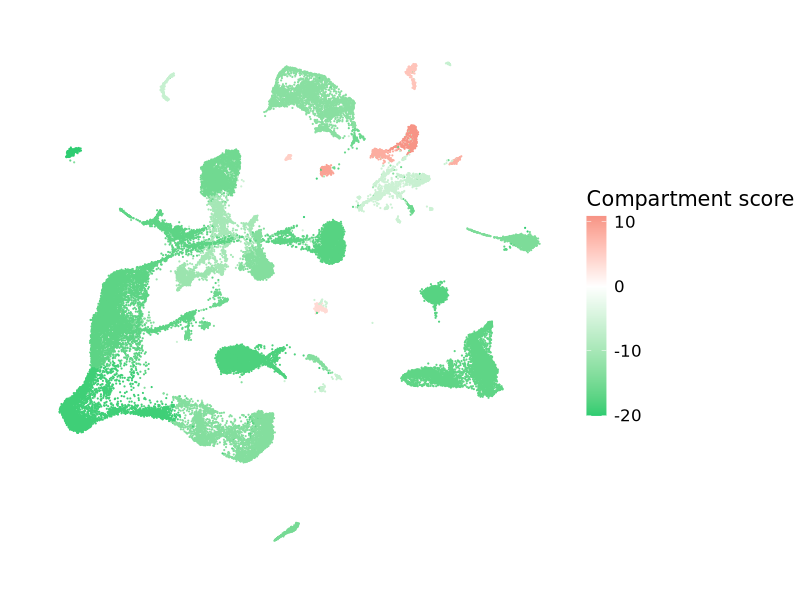

In [41]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2ecc71", mid = "#FFFFFF", high = "#D7272A", midpoint = 0) +
    guides(color = guide_colorbar(barwidth = 1, barheight = 10),limits = c(-20, 20))

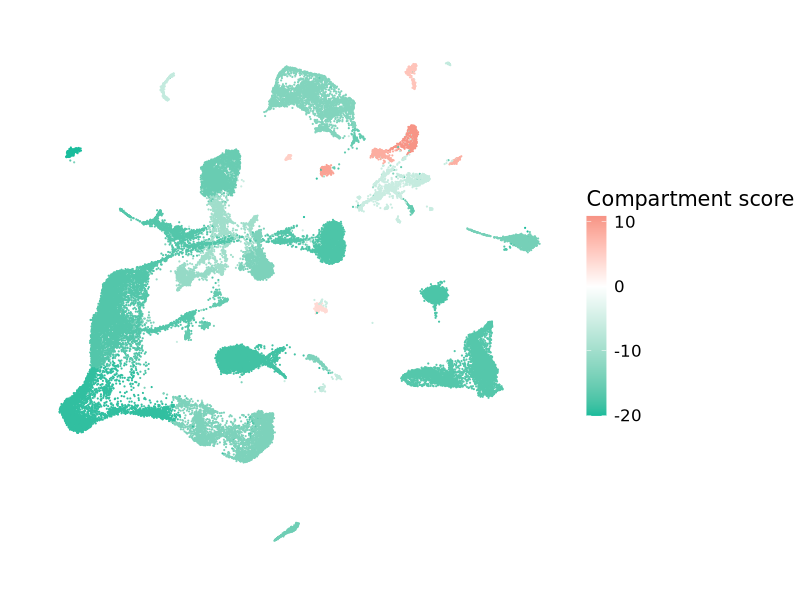

In [42]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#1abc9c", mid = "#FFFFFF", high = "#D7272A", midpoint = 0) +
    guides(color = guide_colorbar(barwidth = 1, barheight = 10),limits = c(-20, 20))

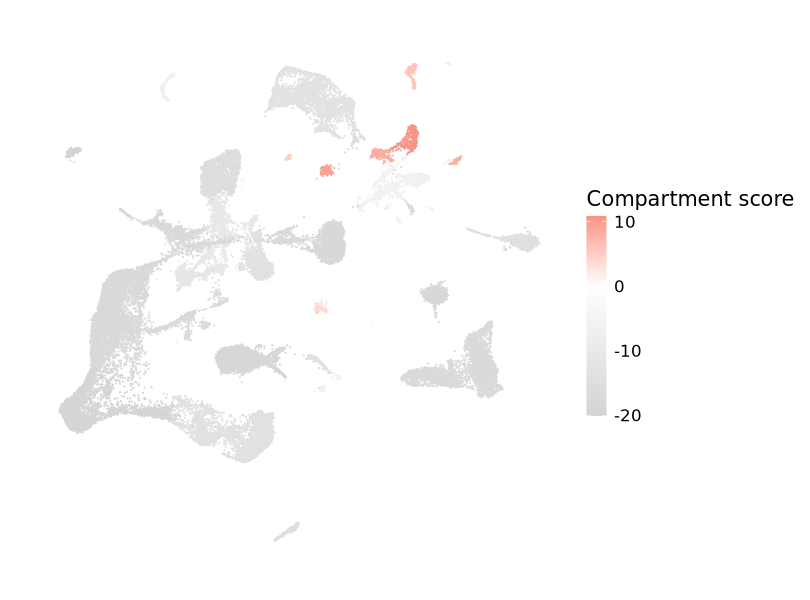

In [43]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "lightgrey", mid = "#FFFFFF", high = "#D7272A", midpoint = 0) +
    guides(color = guide_colorbar(barwidth = 1, barheight = 10),limits = c(-20, 20))

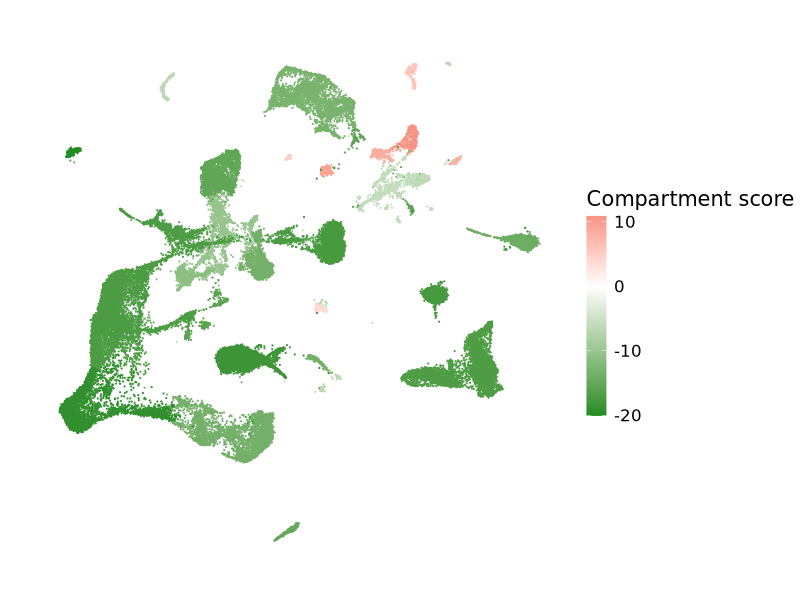

In [44]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#228B22", mid = "#FFFFFF", high = "#D7272A", midpoint = 0) +
    guides(color = guide_colorbar(barwidth = 1, barheight = 10),limits = c(-20, 20))

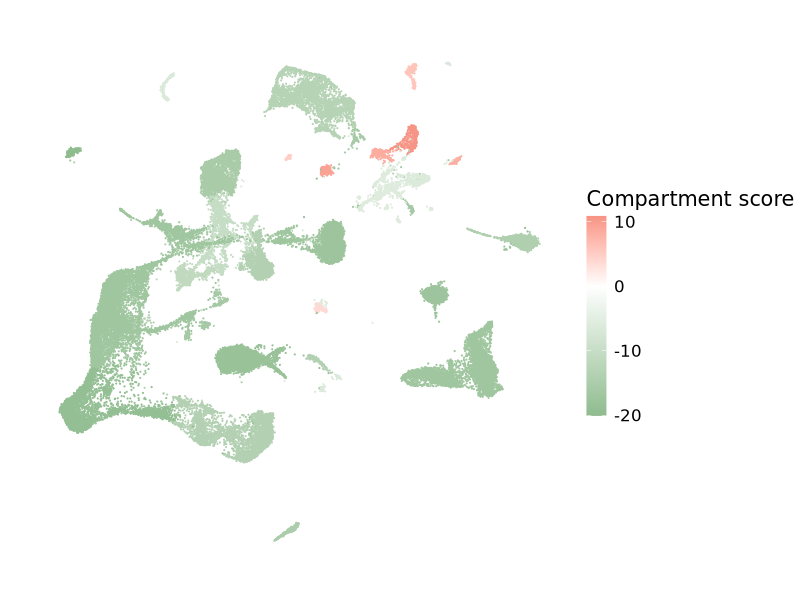

In [45]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0) +
    guides(color = guide_colorbar(barwidth = 1, barheight = 10),limits = c(-20, 20))

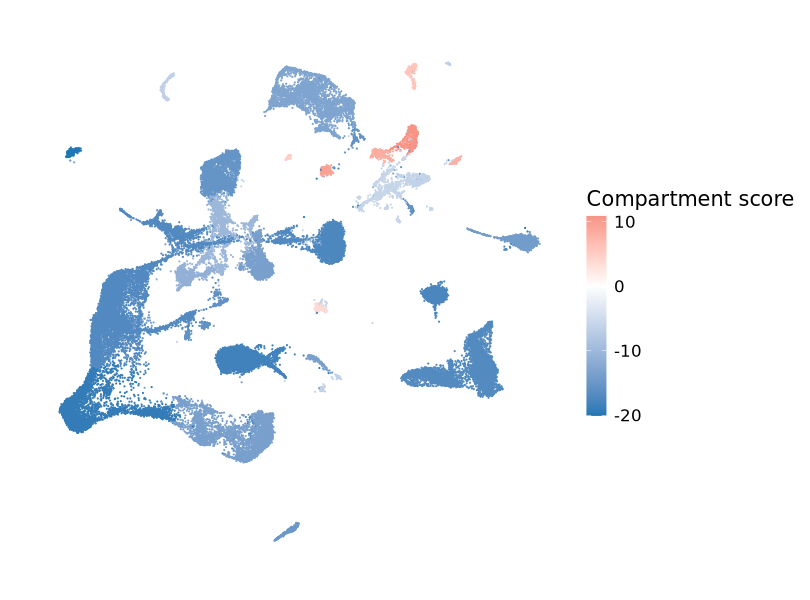

In [44]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#D7272A", midpoint = 0) +
    guides(color = guide_colorbar(barwidth = 1, barheight = 10),limits = c(-20, 20))

In [48]:
merged_df_max_3C %>% t()

,Compartment score
chrom100k,chr6_91
L2/3 IT CTX Glut,-17.13339
L4/5 IT CTX Glut,-19.17048
L5 IT CTX Glut,-13.63979
L2/3 IT RSP Glut,-15.78872
L4 RSP-ACA Glut,-6.439106
L5 ET CTX Glut,-11.25715
SUB-ProS Glut,-10.22113
CA1-ProS Glut,-15.41874
CA3 Glut,-13.59157


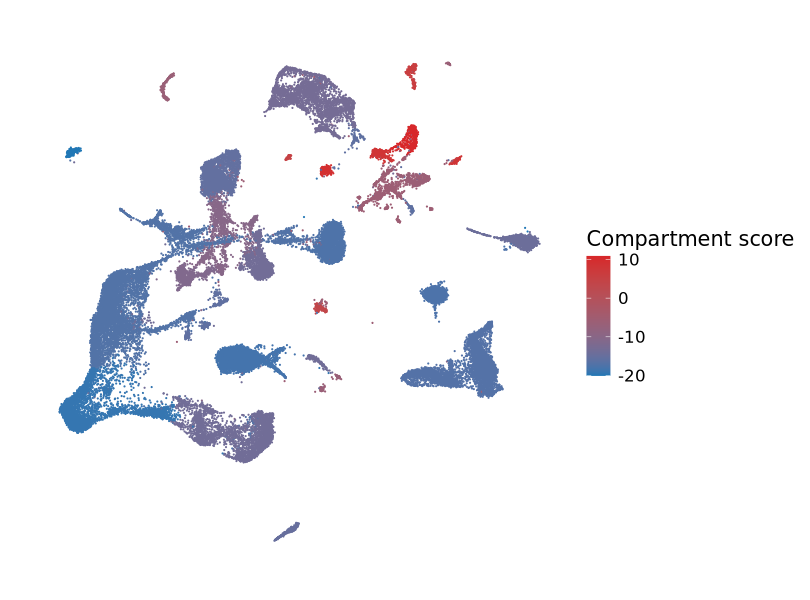

In [49]:
ggplot(UMAP_filter[,c("umap_1","umap_2","Compartment score")], aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size=0.1) +
#     labs(x = "", y = "",title = "3C A/B compartment score") +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "#2077B5", high = "#D7272A")

In [50]:
range(UMAP_filter$`Compartment score`)

[1] -20.05058  10.85344

In [51]:
# range(UMAP_filter$`Compartment score`)

In [52]:
summary(UMAP_filter$`Compartment score`)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 -20.05  -17.53  -16.98  -14.31  -13.59   10.85 

In [53]:
table(UMAP_filter$`Compartment score` > 0)


FALSE  TRUE 
41853  2352 

In [54]:
table(UMAP_filter$`Compartment score` > 10)


FALSE  TRUE 
43655   550 

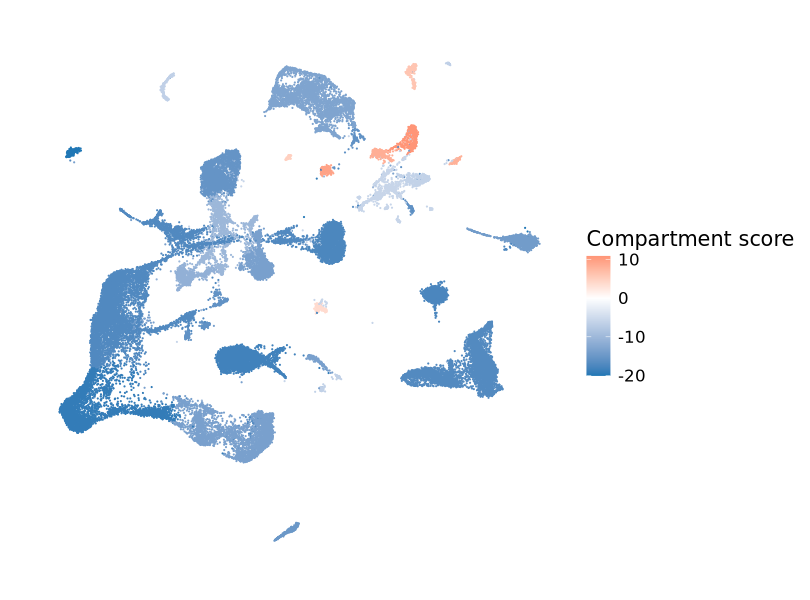

In [45]:
ggplot(UMAP_filter[,c("umap_1","umap_2","Compartment score")], aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#FF0000", midpoint = 0)

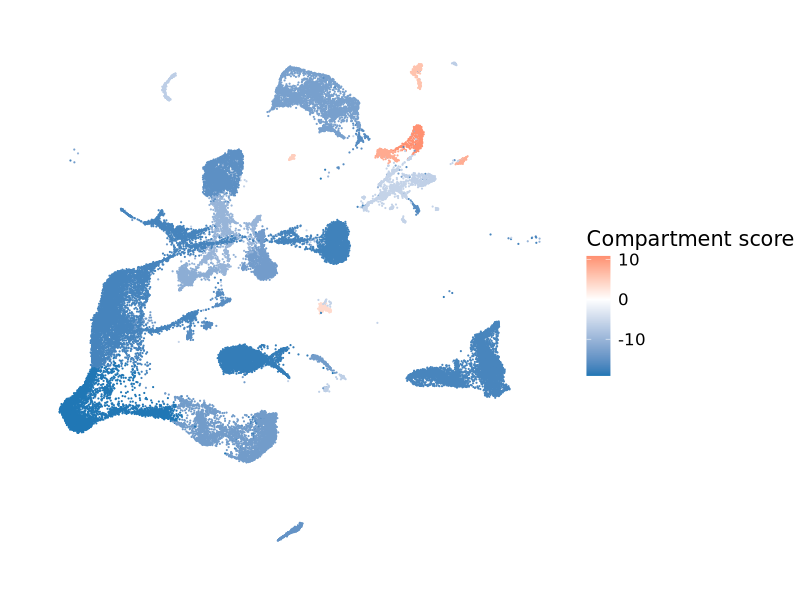

In [47]:
# ggplot(UMAP_filter[,c("umap_1","umap_2","Compartment score")], aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
#     geom_point(size=0.1) +
#     labs(x = "", y = "", title = "") +
#     theme_minimal() +
#     theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
#           axis.ticks = element_blank()) +
#     scale_color_gradient2(low = "#2077B5", mid = "#FFFFFF", high = "#FF0000", midpoint = 0)

In [41]:
library(scales)

Warning message:
“package ‘scales’ was built under R version 4.3.2”


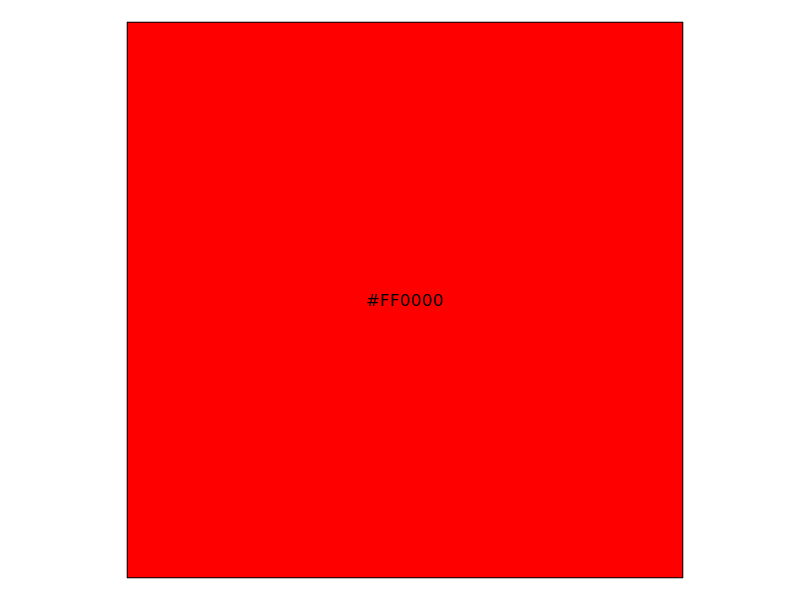

In [46]:
show_col("#FF0000")

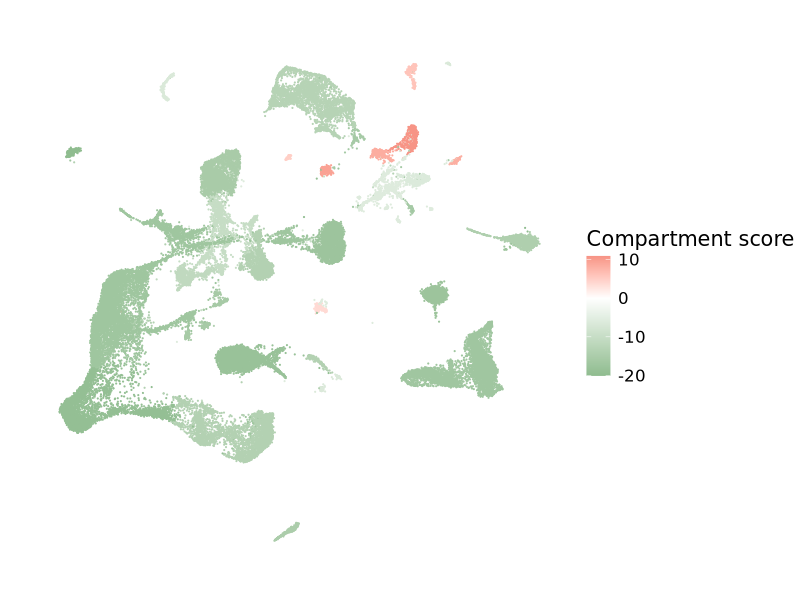

In [47]:
ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)

In [48]:
p1 <- ggplot(UMAP_filter, aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
    geom_point(size = 0.1) +
    labs(x = "", y = "", title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15), panel.grid = element_blank(), axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient2(low = "#8FBC8F", mid = "#FFFFFF", high = "#D7272A", midpoint = 0)

In [49]:
# p1 <- ggplot(UMAP_filter[,c("umap_1","umap_2","Compartment score")], aes(x = umap_1, y = umap_2, color = `Compartment score`)) +
#     geom_point(size=0.8) +
# #     labs(x = "", y = "",title = "3C A/B compartment score") +
#     labs(x = "", y = "",title = "") +
#     theme_minimal() +
#     theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
#           axis.ticks = element_blank()) +
#     scale_color_gradient(low = "#2077B5", high = "#D7272A")

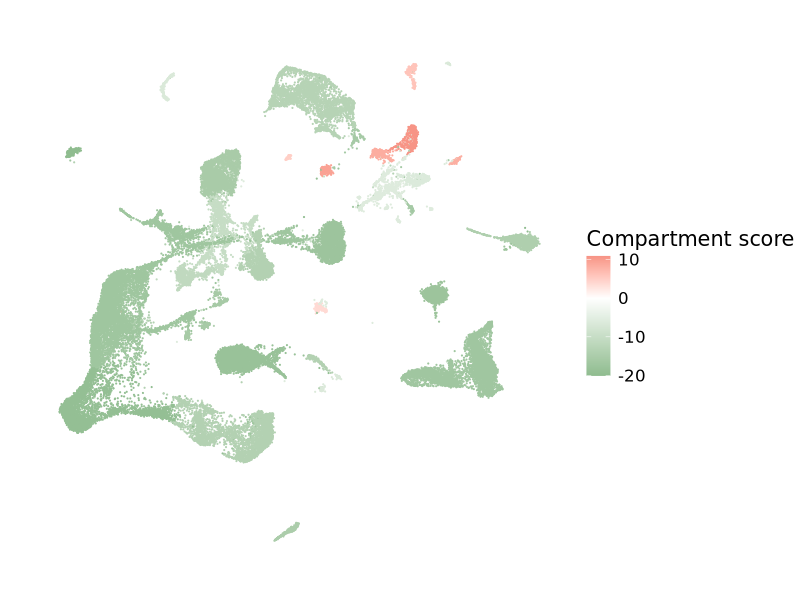

In [50]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
p1

In [ ]:
chrom100k_5hmCG <- read.csv(paste0(indir,"/11-extracted_chr6_91_5hmCG.csv"))

In [52]:
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

,Unique_ID,chr6_91
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.2650602
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.3200000
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.6428571
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.0800000
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.2333333
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.2962963


[1] 44608     2

In [53]:
table(is.na(chrom100k_5hmCG$chr6_91))


FALSE  TRUE 
38578  6030 

In [54]:
RNA_qc_subset <- RNA_qc %>%
  select(Unique_ID, subclass_label)

In [55]:
chrom100k_5hmCG <- chrom100k_5hmCG %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)

,Unique_ID,chr6_91,subclass_label
,<chr>,<dbl>,<chr>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.2650602,L2/3 IT CTX Glut
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.3200000,L2/3 IT CTX Glut
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.6428571,ACB-BST-FS D1 Gaba
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.0800000,L2/3 IT CTX Glut
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.2333333,L2/3 IT CTX Glut
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.2962963,L5 IT CTX Glut


[1] 44608     3

In [56]:
chrom100k_5hmCG <- chrom100k_5hmCG %>%
  group_by(subclass_label) %>%
  mutate(chr6_91 = ifelse(is.na(chr6_91), mean(chr6_91, na.rm = TRUE), chr6_91)) %>%
  ungroup()
head(chrom100k_5hmCG);dim(chrom100k_5hmCG)
table(is.na(chrom100k_5hmCG$chr6_91))

Unique_ID,chr6_91,subclass_label
<chr>,<dbl>,<chr>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.2650602,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.3200000,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.6428571,ACB-BST-FS D1 Gaba
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.0800000,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.2333333,L2/3 IT CTX Glut
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.2962963,L5 IT CTX Glut


[1] 44608     3


FALSE 
44608 

In [57]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass,Compartment score
,<dbl>,<dbl>,<chr>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,-17.133390
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,-17.133390
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-5.867074
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,-17.133390
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,-17.133390
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,-13.639790


[1] 44205     4

In [58]:
table(rownames(UMAP_filter) %in% chrom100k_5hmCG$Unique_ID)
table(chrom100k_5hmCG$Unique_ID %in% rownames(UMAP_filter))


 TRUE 
44205 


FALSE  TRUE 
  403 44205 

In [ ]:
chrom100k_5mCG <- read.csv(paste0(indir,"/11-extracted_chr6_91_5mCG.csv"))
head(chrom100k_5mCG);dim(chrom100k_5mCG)

,Unique_ID,chr6_91
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.8490566
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.8958333
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.8461539
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.8636364
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.8275862
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.9473684


[1] 44608     2

In [60]:
chrom100k_5mCG <- chrom100k_5mCG %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
chrom100k_5mCG <- chrom100k_5mCG %>%
  group_by(subclass_label) %>%
  mutate(chr6_91 = ifelse(is.na(chr6_91), mean(chr6_91, na.rm = TRUE), chr6_91)) %>%
  ungroup()

In [ ]:
chrom100k_true5mCG <- read.csv(paste0(indir,"/11-extracted_chr6_91_true5mCG.csv"))
head(chrom100k_true5mCG);dim(chrom100k_true5mCG)

,Unique_ID,chr6_91
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.5839964
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.5758333
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.2032967
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.7836364
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.5942529
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.6510721


[1] 44608     2

In [62]:
chrom100k_true5mCG <- chrom100k_true5mCG %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
chrom100k_true5mCG <- chrom100k_true5mCG %>%
  group_by(subclass_label) %>%
  mutate(chr6_91 = ifelse(is.na(chr6_91), mean(chr6_91, na.rm = TRUE), chr6_91)) %>%
  ungroup()

In [ ]:
chrom100k_5hmCH <- read.csv(paste0(indir,"/11-extracted_chr6_91_5hmCH.csv"))
head(chrom100k_5hmCH);dim(chrom100k_5hmCH)
chrom100k_5mCH <- read.csv(paste0(indir,"/11-extracted_chr6_91_5mCH.csv"))
head(chrom100k_5mCH);dim(chrom100k_5mCH)
chrom100k_true5mCH <- read.csv(paste0(indir,"/11-extracted_chr6_91_true5mCH.csv"))
head(chrom100k_true5mCH);dim(chrom100k_true5mCH)

,Unique_ID,chr6_91
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.001740947
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.006806580
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.009771987
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.002272727
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.001058201
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.003875969


[1] 44608     2

,Unique_ID,chr6_91
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.02847403
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.04274005
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.02135774
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.03835425
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.01881331
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.03913043


[1] 44608     2

,Unique_ID,chr6_91
,<chr>,<dbl>
1,P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,0.02673309
2,P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,0.03593347
3,P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,0.01158576
4,P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,0.03608153
5,P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,0.01775511
6,P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,0.03525446


[1] 44608     2

In [64]:
chrom100k_5hmCH <- chrom100k_5hmCH %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
chrom100k_5hmCH <- chrom100k_5hmCH %>%
  group_by(subclass_label) %>%
  mutate(chr6_91 = ifelse(is.na(chr6_91), mean(chr6_91, na.rm = TRUE), chr6_91)) %>%
  ungroup()

chrom100k_5mCH <- chrom100k_5mCH %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
chrom100k_5mCH <- chrom100k_5mCH %>%
  group_by(subclass_label) %>%
  mutate(chr6_91 = ifelse(is.na(chr6_91), mean(chr6_91, na.rm = TRUE), chr6_91)) %>%
  ungroup()

chrom100k_true5mCH <- chrom100k_true5mCH %>%
  left_join(RNA_qc_subset, by = "Unique_ID")
chrom100k_true5mCH <- chrom100k_true5mCH %>%
  group_by(subclass_label) %>%
  mutate(chr6_91 = ifelse(is.na(chr6_91), mean(chr6_91, na.rm = TRUE), chr6_91)) %>%
  ungroup()

In [65]:
# table(is.na(chrom100k_5mCG$chr6_91))
# table(is.na(chrom100k_true5mCG$chr6_91))
# table(is.na(chrom100k_5hmCH$chr6_91))
# table(is.na(chrom100k_true5mCH$chr6_91))
# table(is.na(chrom100k_5mCH$chr6_91))

In [66]:
table(is.na(chrom100k_5mCG$chr6_91))
table(is.na(chrom100k_true5mCG$chr6_91))
table(is.na(chrom100k_5hmCH$chr6_91))
table(is.na(chrom100k_true5mCH$chr6_91))
table(is.na(chrom100k_5mCH$chr6_91))


FALSE 
44608 


FALSE 
44608 


FALSE 
44608 


FALSE 
44608 


FALSE 
44608 

In [67]:
table(rownames(UMAP_filter) %in% chrom100k_5mCG$Unique_ID)
table(rownames(UMAP_filter) %in% chrom100k_true5mCG$Unique_ID)
table(rownames(UMAP_filter) %in% chrom100k_5hmCH$Unique_ID)
table(rownames(UMAP_filter) %in% chrom100k_true5mCH$Unique_ID)
table(rownames(UMAP_filter) %in% chrom100k_5mCH$Unique_ID)


 TRUE 
44205 


 TRUE 
44205 


 TRUE 
44205 


 TRUE 
44205 


 TRUE 
44205 

In [68]:
UMAP_filter$`5hmCG` <- chrom100k_5hmCG$chr6_91[match(rownames(UMAP_filter),chrom100k_5hmCG$Unique_ID)]
UMAP_filter$`5hmCG+5mCG` <- chrom100k_5mCG$chr6_91[match(rownames(UMAP_filter),chrom100k_5mCG$Unique_ID)]
UMAP_filter$`5mCG` <- chrom100k_true5mCG$chr6_91[match(rownames(UMAP_filter),chrom100k_true5mCG$Unique_ID)]
UMAP_filter$`5hmCH` <- chrom100k_5hmCH$chr6_91[match(rownames(UMAP_filter),chrom100k_5hmCH$Unique_ID)]
UMAP_filter$`5hmCH+5mCH` <- chrom100k_5mCH$chr6_91[match(rownames(UMAP_filter),chrom100k_5mCH$Unique_ID)]
UMAP_filter$`5mCH` <- chrom100k_true5mCH$chr6_91[match(rownames(UMAP_filter),chrom100k_true5mCH$Unique_ID)]

In [69]:
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass,Compartment score,5hmCG,5hmCG+5mCG,5mCG,5hmCH,5hmCH+5mCH,5mCH
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,-17.133390,0.2650602,0.8490566,0.5839964,0.001740947,0.02847403,0.02673309
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,-17.133390,0.3200000,0.8958333,0.5758333,0.006806580,0.04274005,0.03593347
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-5.867074,0.6428571,0.8461539,0.2032967,0.009771987,0.02135774,0.01158576
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,-17.133390,0.0800000,0.8636364,0.7836364,0.002272727,0.03835425,0.03608153
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,-17.133390,0.2333333,0.8275862,0.5942529,0.001058201,0.01881331,0.01775511
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,-13.639790,0.2962963,0.9473684,0.6510721,0.003875969,0.03913043,0.03525446


[1] 44205    10

In [70]:
UMAP_filter <- na.omit(UMAP_filter)
head(UMAP_filter);dim(UMAP_filter)

,umap_1,umap_2,subclass,Compartment score,5hmCG,5hmCG+5mCG,5mCG,5hmCH,5hmCH+5mCH,5mCH
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P56_Male_SuperficialCortex_TSO_plate37.AACCAGAG,-10.619191,-3.305625,L2/3 IT CTX Glut,-17.133390,0.2650602,0.8490566,0.5839964,0.001740947,0.02847403,0.02673309
P56_Male_SuperficialCortex_TSO_plate37.AAGACACC,-6.353836,1.983629,L2/3 IT CTX Glut,-17.133390,0.3200000,0.8958333,0.5758333,0.006806580,0.04274005,0.03593347
P56_Male_SuperficialCortex_TSO_plate37.AAGACCGT,6.901790,7.256326,ACB-BST-FS D1 Gaba,-5.867074,0.6428571,0.8461539,0.2032967,0.009771987,0.02135774,0.01158576
P56_Male_SuperficialCortex_TSO_plate37.AGACCTTG,-10.278223,-0.180405,L2/3 IT CTX Glut,-17.133390,0.0800000,0.8636364,0.7836364,0.002272727,0.03835425,0.03608153
P56_Male_SuperficialCortex_TSO_plate37.AGACGCTA,-8.274960,-4.000308,L2/3 IT CTX Glut,-17.133390,0.2333333,0.8275862,0.5942529,0.001058201,0.01881331,0.01775511
P56_Male_SuperficialCortex_TSO_plate37.AGCCTATC,-4.735382,-9.954310,L5 IT CTX Glut,-13.639790,0.2962963,0.9473684,0.6510721,0.003875969,0.03913043,0.03525446


[1] 44205    10

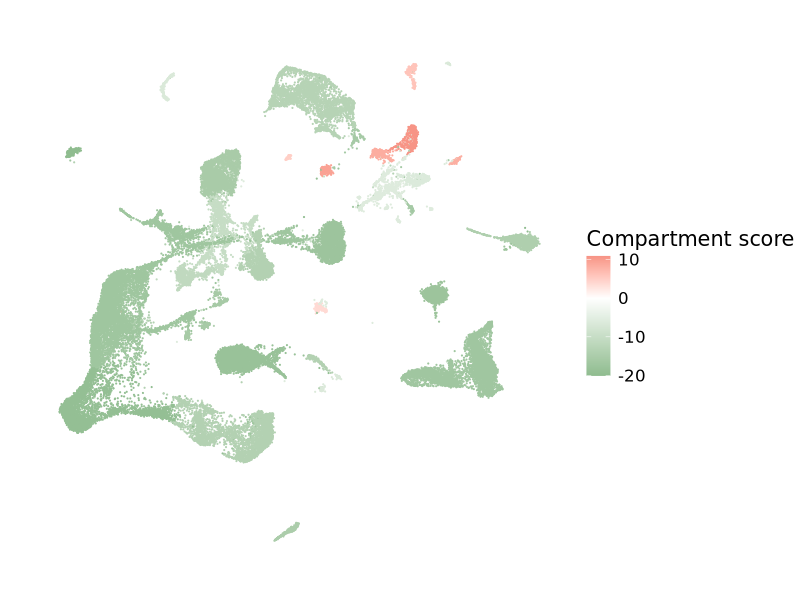

In [71]:
options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
p1

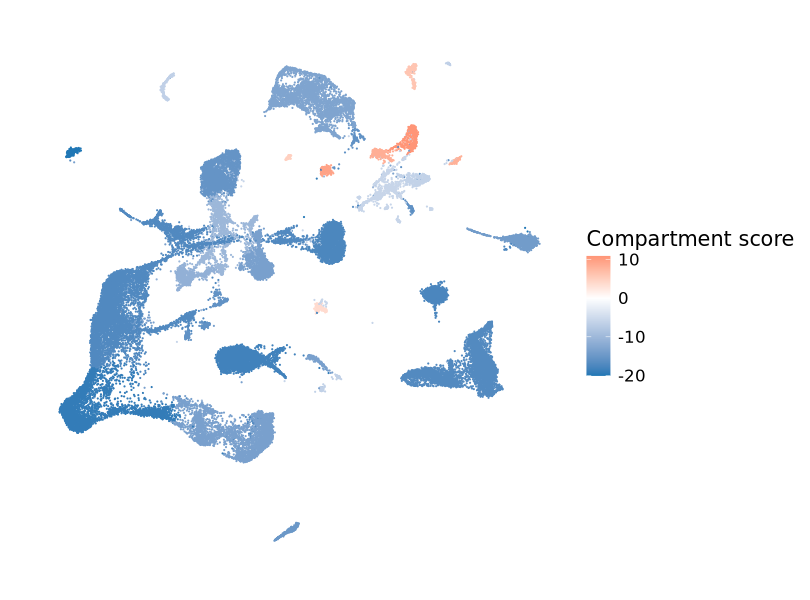

In [80]:
# options(repr.plot.width = 8.1, repr.plot.height = 6, repr.plot.res = 100)
# p1

In [72]:
aaa <- UMAP_filter

In [121]:
UMAP_filter <- aaa

In [122]:
range(UMAP_filter$`5hmCG`)

[1] 0 1

In [123]:
UMAP_filter[["5hmCG"]] <- pmin(pmax(UMAP_filter[["5hmCG"]], 0.2), 0.5)

In [124]:
range(UMAP_filter$`5hmCG`)

[1] 0.2 0.5

In [125]:
p2 <- ggplot(UMAP_filter[,c("umap_1","umap_2","5hmCG")], aes(x = umap_1, y = umap_2, color = `5hmCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.2, 0.5), breaks = c(0.2, 0.5))

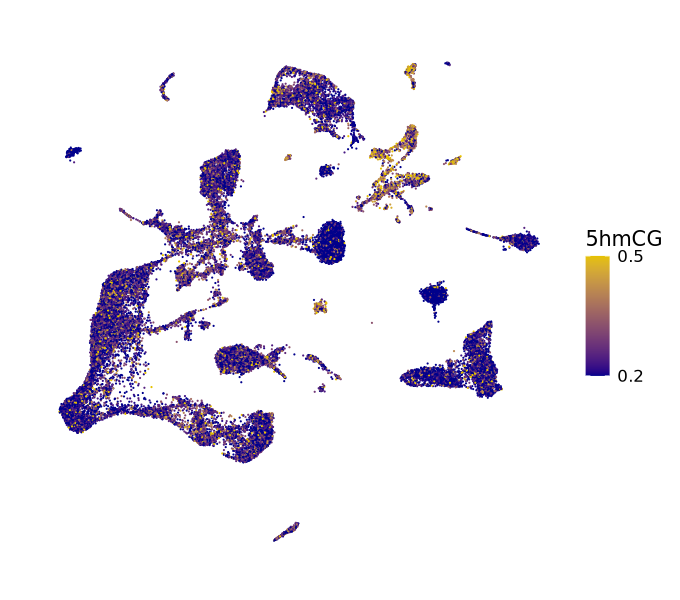

In [126]:
options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
p2

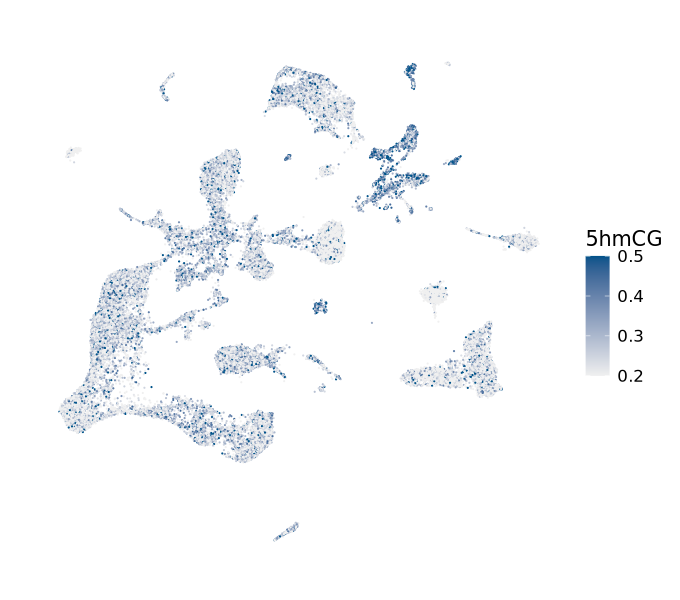

In [79]:
options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
p2

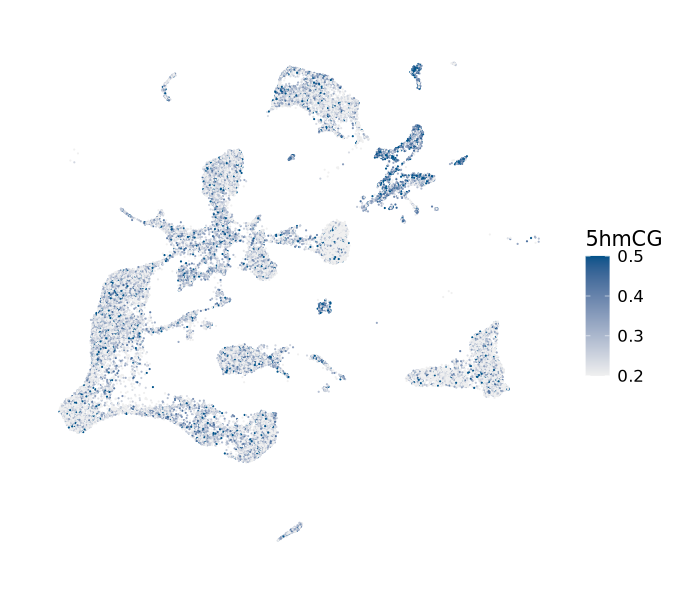

In [81]:
# options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
# p2

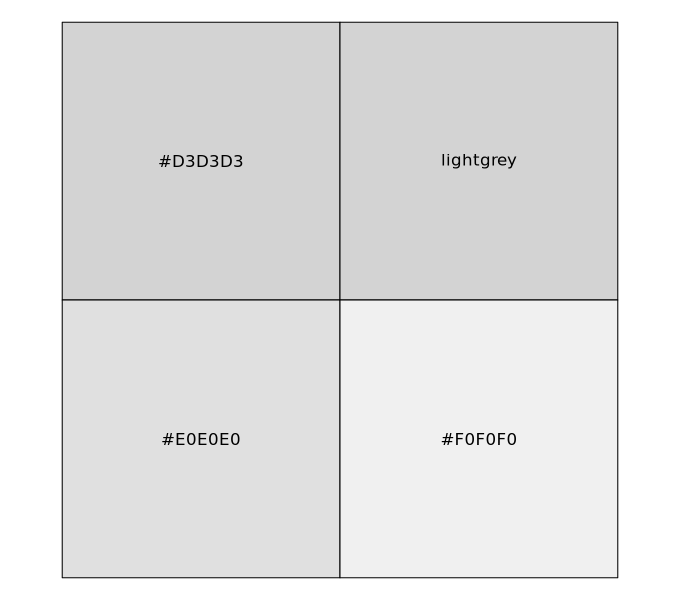

In [89]:
show_col(c("#D3D3D3","lightgrey","#E0E0E0","#F0F0F0"))

In [127]:
UMAP_filter[["5hmCG+5mCG"]] <- pmin(pmax(UMAP_filter[["5hmCG+5mCG"]], 0.3), 1)

In [128]:
p3 <- ggplot(UMAP_filter[,c("umap_1","umap_2","5hmCG+5mCG")], aes(x = umap_1, y = umap_2, color = `5hmCG+5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.3, 1), breaks = c(0.3, 1))

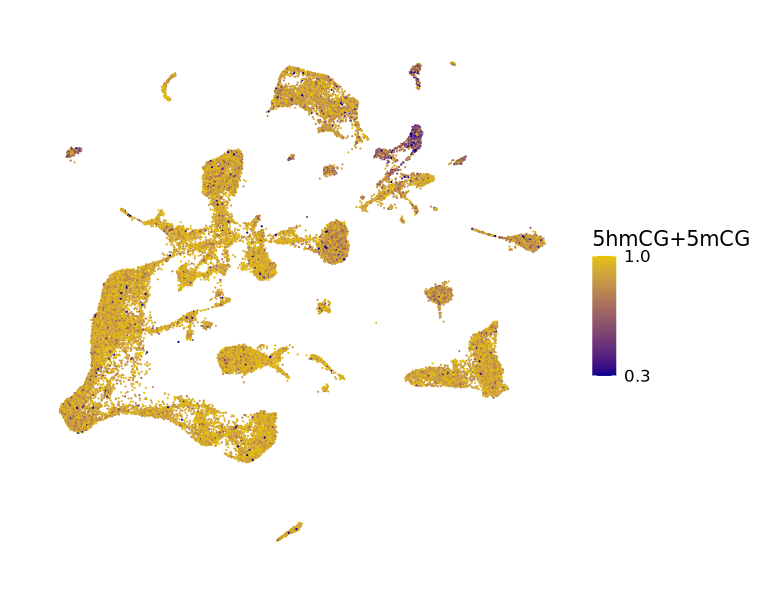

In [129]:
options(repr.plot.width = 7.7, repr.plot.height = 6, repr.plot.res = 100)
p3

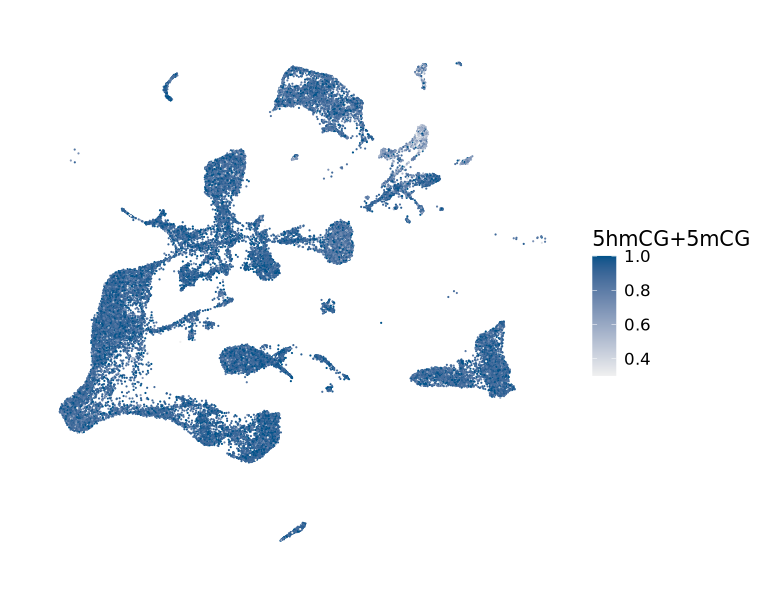

In [85]:
# options(repr.plot.width = 7.7, repr.plot.height = 6, repr.plot.res = 100)
# p3

In [131]:
UMAP_filter[["5mCG"]] <- pmin(pmax(UMAP_filter[["5mCG"]], 0.3), 0.8)

In [132]:
p4 <- ggplot(UMAP_filter[,c("umap_1","umap_2","5mCG")], aes(x = umap_1, y = umap_2, color = `5mCG`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#e6c200", limits = c(0.3, 0.8), breaks = c(0.3, 0.8))

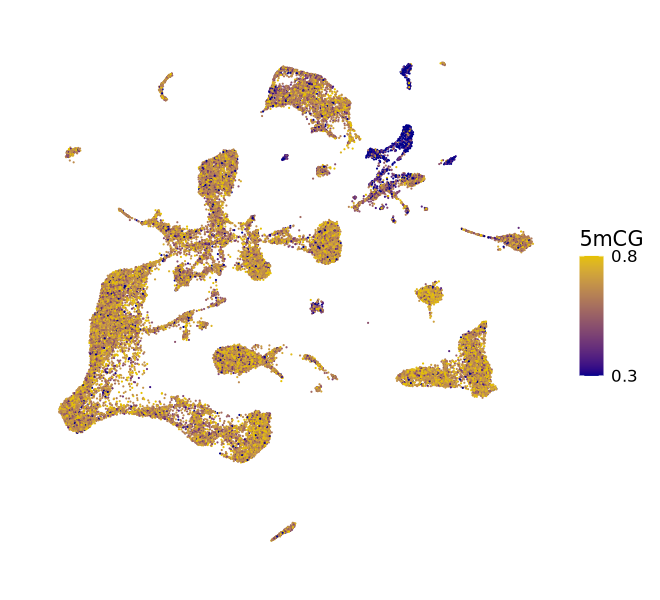

In [133]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
p4

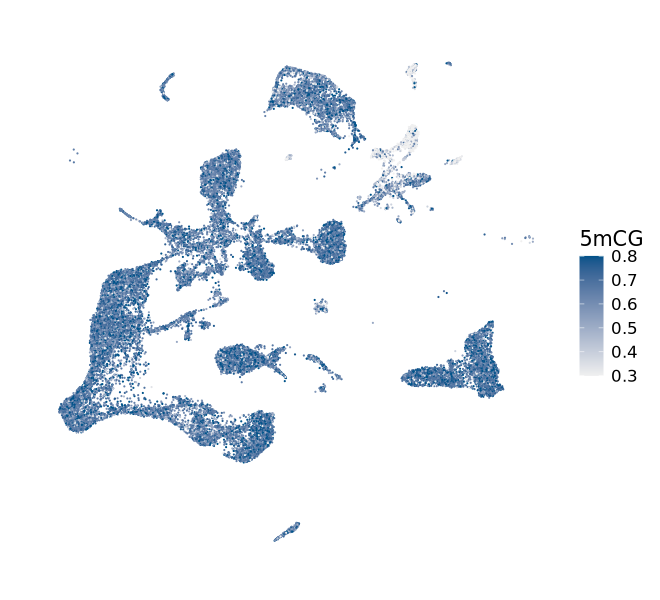

In [88]:
# options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
# p4

In [108]:
UMAP_filter[["5hmCH"]] <- pmin(pmax(UMAP_filter[["5hmCH"]], 0), 0.02)

In [109]:
p5 <- ggplot(UMAP_filter[,c("umap_1","umap_2","5hmCH")], aes(x = umap_1, y = umap_2, color = `5hmCH`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#75D054FF", limits = c(0, 0.02), breaks = c(0, 0.02))

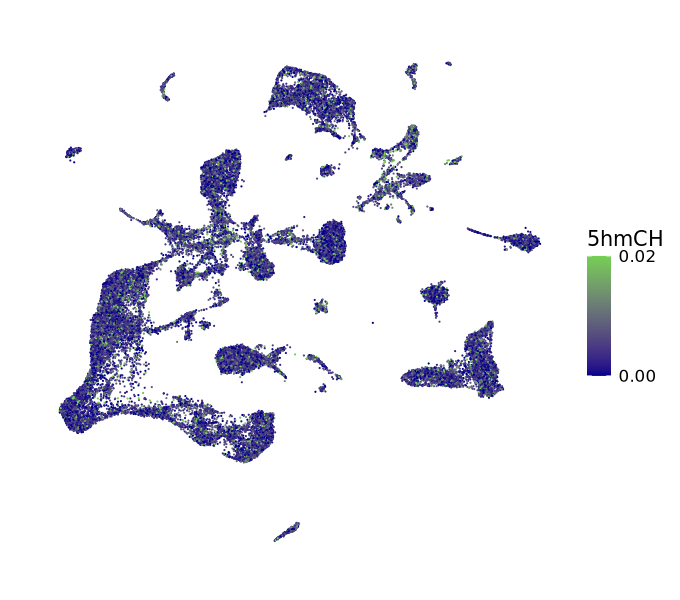

In [110]:
options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
p5

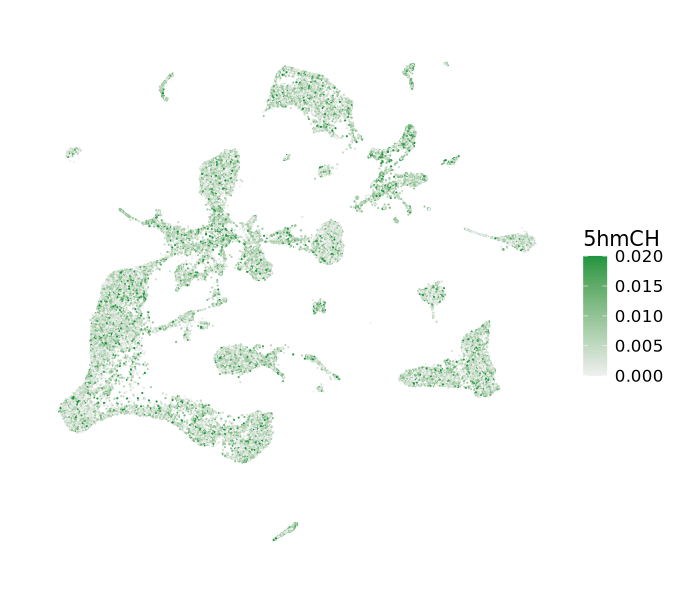

In [89]:
options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
p5

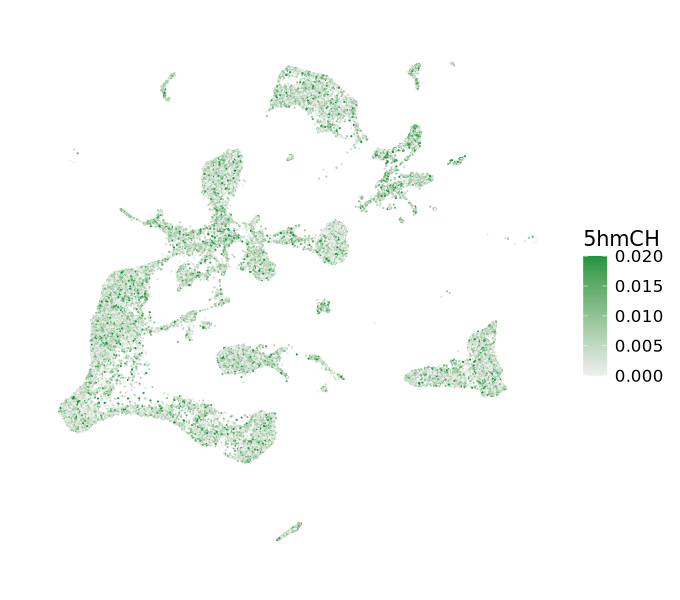

In [91]:
# options(repr.plot.width = 6.8, repr.plot.height = 6, repr.plot.res = 100)
# p5

In [111]:
UMAP_filter[["5hmCH+5mCH"]] <- pmin(pmax(UMAP_filter[["5hmCH+5mCH"]], 0), 0.03)

In [112]:
p6 <- ggplot(UMAP_filter[,c("umap_1","umap_2","5hmCH+5mCH")], aes(x = umap_1, y = umap_2, color = `5hmCH+5mCH`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#75D054FF", limits = c(0, 0.03), breaks = c(0, 0.03))

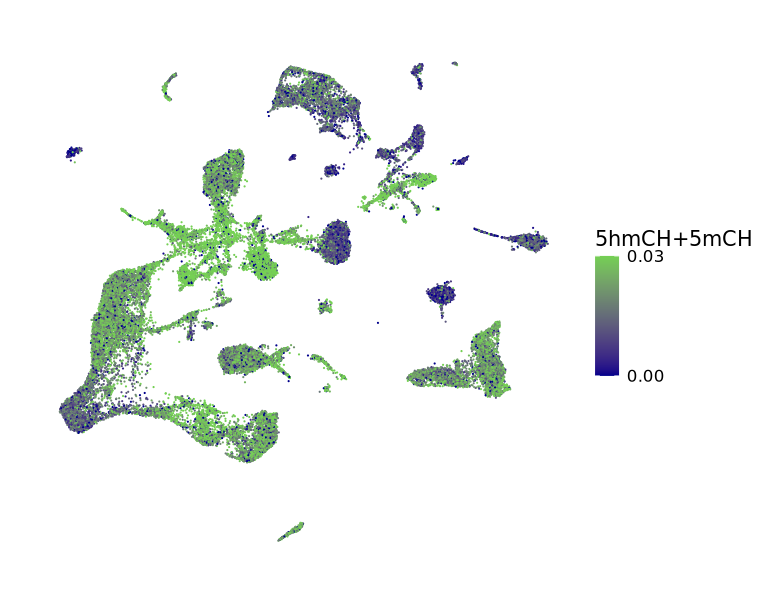

In [113]:
options(repr.plot.width = 7.7, repr.plot.height = 6, repr.plot.res = 100)
p6

In [114]:
UMAP_filter[["5mCH"]] <- pmin(pmax(UMAP_filter[["5mCH"]], 0), 0.03)

In [115]:
p7 <- ggplot(UMAP_filter[,c("umap_1","umap_2","5mCH")], aes(x = umap_1, y = umap_2, color = `5mCH`)) +
    geom_point(size=0.1) +
    labs(x = "", y = "",title = "") +
    theme_minimal() +
    theme(text = element_text(size = 15),panel.grid = element_blank(),axis.text = element_blank(),
          axis.ticks = element_blank()) +
    scale_color_gradient(low = "darkblue", high = "#75D054FF", limits = c(0, 0.03), breaks = c(0, 0.03))

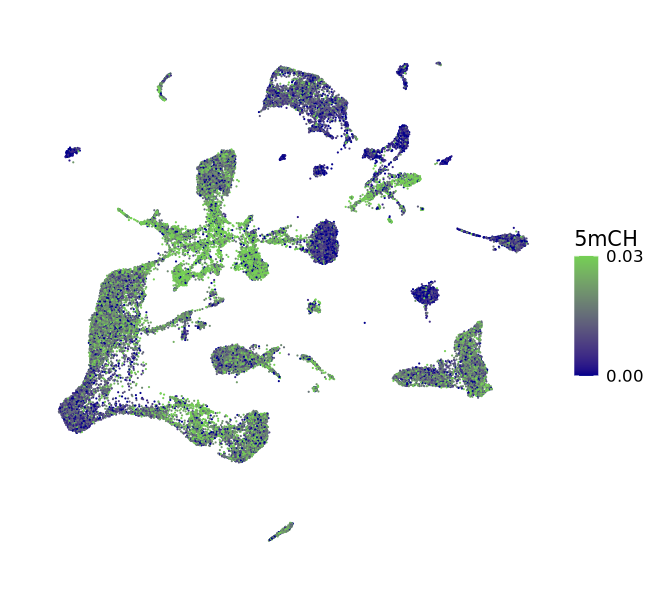

In [116]:
options(repr.plot.width = 6.6, repr.plot.height = 6, repr.plot.res = 100)
p7

In [117]:
library(gridExtra)
library(ggplot2)


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [134]:
gpp1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(8.1, "inches"))
gpp2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(6.8, "inches"))
gpp3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(7.7, "inches"))
gpp4 <- arrangeGrob(p4, heights = unit(6, "inches"), widths = unit(6.6, "inches"))
gpp5 <- arrangeGrob(p5, heights = unit(6, "inches"), widths = unit(6.8, "inches"))
gpp6 <- arrangeGrob(p6, heights = unit(6, "inches"), widths = unit(7.7, "inches"))
gpp7 <- arrangeGrob(p7, heights = unit(6, "inches"), widths = unit(6.6, "inches"))

In [135]:
combined_plot <- arrangeGrob(gpp1, gpp2, gpp3, gpp4, gpp5, gpp6, gpp7, ncol = 4, nrow = 2)

In [ ]:
# ggsave("/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/output/11-UMAP_chr6_91_show_3C_DNA_methyl_including_non_neuron_20250104.pdf", 
#        combined_plot, 
#        width = 33, height = 12)

In [ ]:
ggsave("../../../output/01.Young_Mouse/05-AB_compartment/11-UMAP_chr6_91_show_3C_DNA_methyl_including_non_neuron_20250106_0.3-0.8.pdf", 
       combined_plot, 
       width = 33, height = 12)